**importing libraries**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
#just to silence the annoying warnings :
import warnings
warnings.filterwarnings("ignore")

#plot styling :
#default size is 6x4 which is tiny ,so:
plt.rcParams['figure.figsize']=(12,6)
plt.rcParams["font.size"]=12
#clean readable background :
sns.set_style("whitegrid")




load the data

In [29]:
import pandas as pd
dataset=pd.read_csv("/content/OnlineNewsPopularity.csv")



#cleaning the column names:(columns have a space before it )
dataset.columns=dataset.columns.str.strip()

print("dataset loaded successfully (:")
print("Shape:",dataset.shape)
#printed the number of rows and columns in the dataset
dataset.head()


dataset loaded successfully (:
Shape: (39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


DATA TYPES & MEMORY USAGE

In [30]:

print("datatset info :")
#no missing data
dataset.info(memory_usage='deep')
#so we can get the exact RAM used
print('_'*50)
print(dataset.describe().T)
'''share's mean=(3395.380184)>>50%=median=(1400.000000)?
then data is heavily skewed to the right
..using the mean as the threshold in classification would'nt be fair instead we use
 the median as the threshold beacause it's not affected by the
 outliers(max shares)'''




datatset info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            39644 non-null  object 
 1   timedelta                      39644 non-null  float64
 2   n_tokens_title                 39644 non-null  float64
 3   n_tokens_content               39644 non-null  float64
 4   n_unique_tokens                39644 non-null  float64
 5   n_non_stop_words               39644 non-null  float64
 6   n_non_stop_unique_tokens       39644 non-null  float64
 7   num_hrefs                      39644 non-null  float64
 8   num_self_hrefs                 39644 non-null  float64
 9   num_imgs                       39644 non-null  float64
 10  num_videos                     39644 non-null  float64
 11  average_token_length           39644 non-null  float64
 12  num_keywords                  

"share's mean=(3395.380184)>>50%=median=(1400.000000)?\nthen data is heavily skewed to the right\n..using the mean as the threshold in classification would'nt be fair instead we use\n the median as the threshold beacause it's not affected by the\n outliers(max shares)"

dropping non-predivtive columns :

In [31]:
# Check exact column names first
#print(dataset.columns.tolist())
#had a key error so decided to check how the keya are originally written
columns_to_drop=['url','timedelta']
dataset = dataset.drop(columns=columns_to_drop)
print("Dropped:",columns_to_drop)
print("dataset's new shape:",dataset.shape[0],"rows x",dataset.shape[1],'coulmns')

Dropped: ['url', 'timedelta']
dataset's new shape: 39644 rows x 59 coulmns


handling missing values

missing count: n_tokens_title                   0
n_tokens_content                 0
n_unique_tokens                  0
n_non_stop_words                 0
n_non_stop_unique_tokens         0
num_hrefs                        0
num_self_hrefs                   0
num_imgs                         0
num_videos                       0
average_token_length             0
num_keywords                     0
data_channel_is_lifestyle        0
data_channel_is_entertainment    0
data_channel_is_bus              0
data_channel_is_socmed           0
data_channel_is_tech             0
data_channel_is_world            0
kw_min_min                       0
kw_max_min                       0
kw_avg_min                       0
kw_min_max                       0
kw_max_max                       0
kw_avg_max                       0
kw_min_avg                       0
kw_max_avg                       0
kw_avg_avg                       0
self_reference_min_shares        0
self_reference_max_shares        0
self_

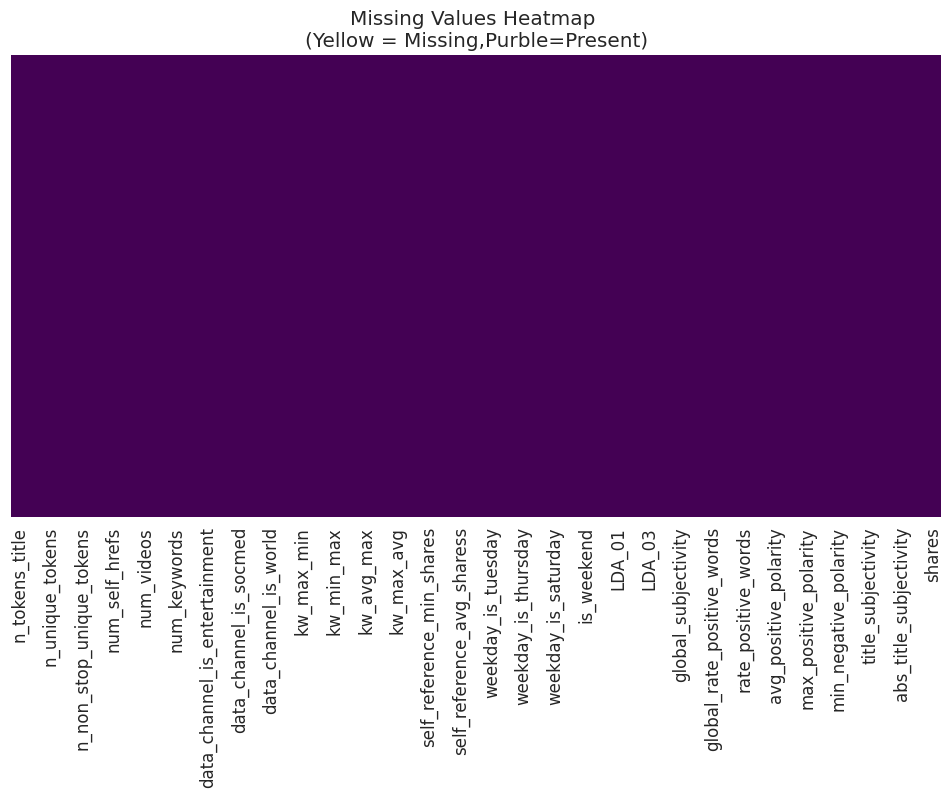

Fig saved


In [32]:
missing=dataset.isnull().sum()
print("missing count:",missing)
print('_'*80)
#no null values in the data set
#just in case :

missing_percentage=(missing/len(dataset))*100
print("missing percentage:",missing_percentage)
print('_'*80)
col_null= missing[missing > 0].index.tolist()
print("columns with null valuses if existed :", col_null)

'''missing returns a series where the column names represent the index
and the values are the # of missing val in each col '''

if len(col_null)==0:
  print("no missing values in the dataset ")

#Visualizing :

sns.heatmap(dataset.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.title("Missing Values Heatmap \n(Yellow = Missing,Purble=Present)")
plt.savefig('missing_values_heatmap.png',dpi=150,bbox_inches='tight')
#dpi=dots per inch(controlling sharpness and resolution or the fanerated image )
plt.show()
print("Fig saved")

duplication detection

In [33]:
duplicate_counts=dataset.duplicated().sum()
'''duplicated checks each row ->returns true if duplicated
,false if not ,sum->counts the #of true rows  '''
duplicate_percentage=(duplicate_counts / len(dataset))*100
print(duplicate_counts)
'''duplicate rows are silent killers because they may bias
 the model ,data leakage ,inflating data'''
if duplicate_counts==0:
  print("no duplicated rows ")
else:
  print("found",duplicate_counts,"duplicates ->will drop them (:")
  dataset=dataset.drop_duplicates()
  print("duplicates r now removed ,dataset's new shape:",dataset.shape)

0
no duplicated rows 


detecting &visualizing outliers

lower: -1835.0 
 upper: 5581.0 
 Q1: 946.0 
 Q3: 2800.0 
 IQR: 1854.0
number of outliers: 4541
the percent of outliers: 11.454444556553325


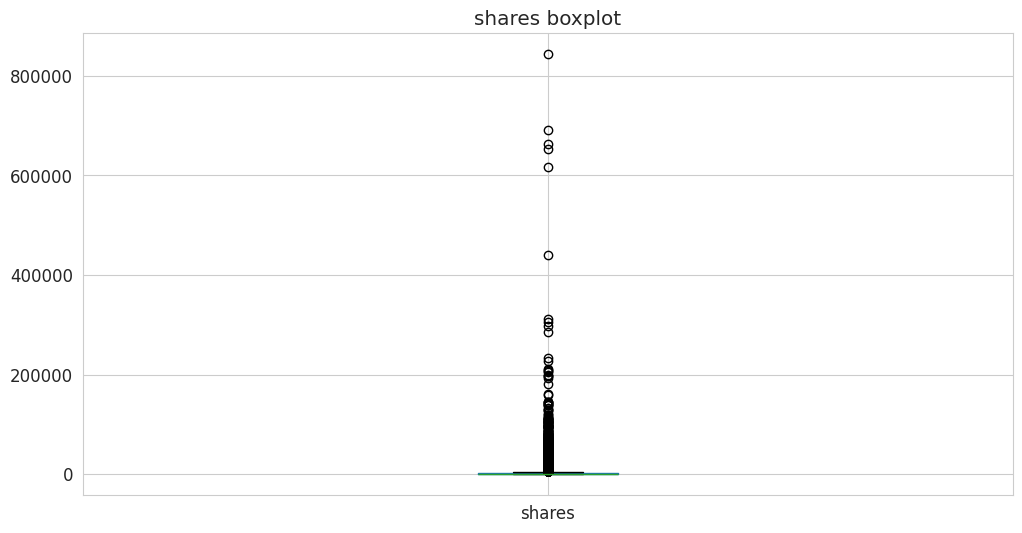

"the data is severly right-skewed ,we cannot drop these outliers since they're real records\n,we'll need to use log transformation here.\nSince the lower fence is negative this assurs to us that there are no lower outliers "

In [34]:
#IQR to detect outliers :
Q1=dataset['shares'].quantile(0.25)
Q3=dataset['shares'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print("lower:",lower,'\n upper:',upper,'\n Q1:',Q1,'\n Q3:',Q3,'\n IQR:',IQR)
outliers=dataset[(dataset['shares']<lower) | (dataset['shares']>upper)]
print("number of outliers:",len(outliers))
print("the percent of outliers:",(len(outliers)/len(dataset))*100)

#visualize:
dataset.boxplot(column="shares")
plt.title("shares boxplot")

plt.show()
#the output shows a significant amount of outliers .. ~ 11.5% of the dataset r outliers ,which tells us :
'''the data is severly right-skewed ,we cannot drop these outliers since they're real records
,we'll need to use log transformation here.
Since the lower fence is negative this assurs to us that there are no lower outliers '''

dealing with outliers

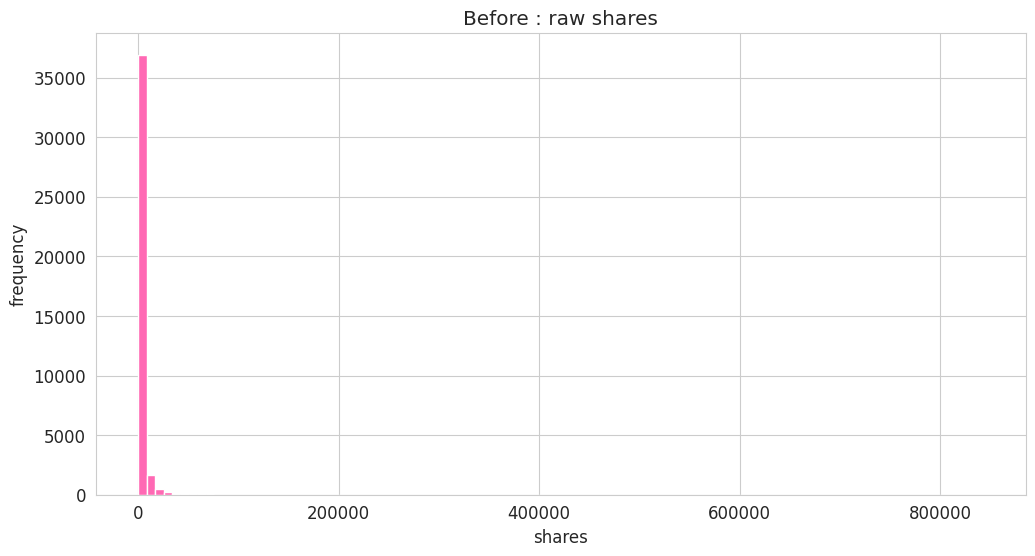

In [35]:
dataset["log_shares"]=np.log1p(dataset['shares'])

'''added the log shares column to the dataset and kept the raw
 shares because we'll need it in task B'''

plt.hist(dataset['shares'],bins=100,color='hotpink')
plt.title("Before : raw shares")
plt.xlabel("shares")
plt.ylabel("frequency")
plt.show()
# where x axis  is the # of shares, y axis is the frequency

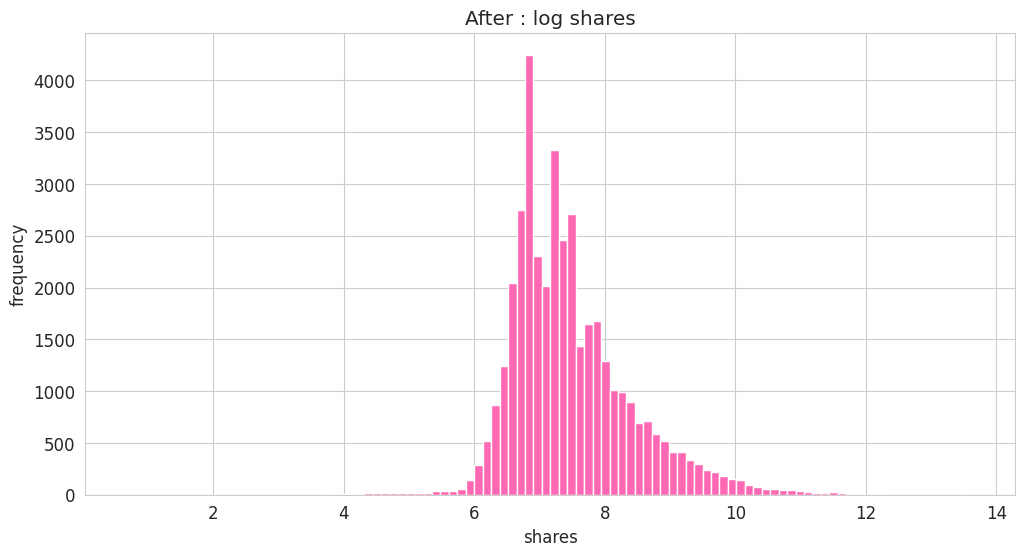

In [36]:
plt.hist(dataset["log_shares"],bins=100,color="hotpink")
plt.title("After : log shares")
plt.xlabel("shares")
plt.ylabel("frequency")
plt.show()
#using log compresse large gaps into manageable ones
# we used log(shares+1) because log(0)=undefined

encoding

In [37]:
text_col=dataset.select_dtypes(include=['object']).columns
print("Text coulmns:",list(text_col))
#actually our data set already uses binary encoding (:
print('did not need encoding')
print("categorical columns already encoded as binary ")

Text coulmns: []
did not need encoding
categorical columns already encoded as binary 


correaltion heatmap

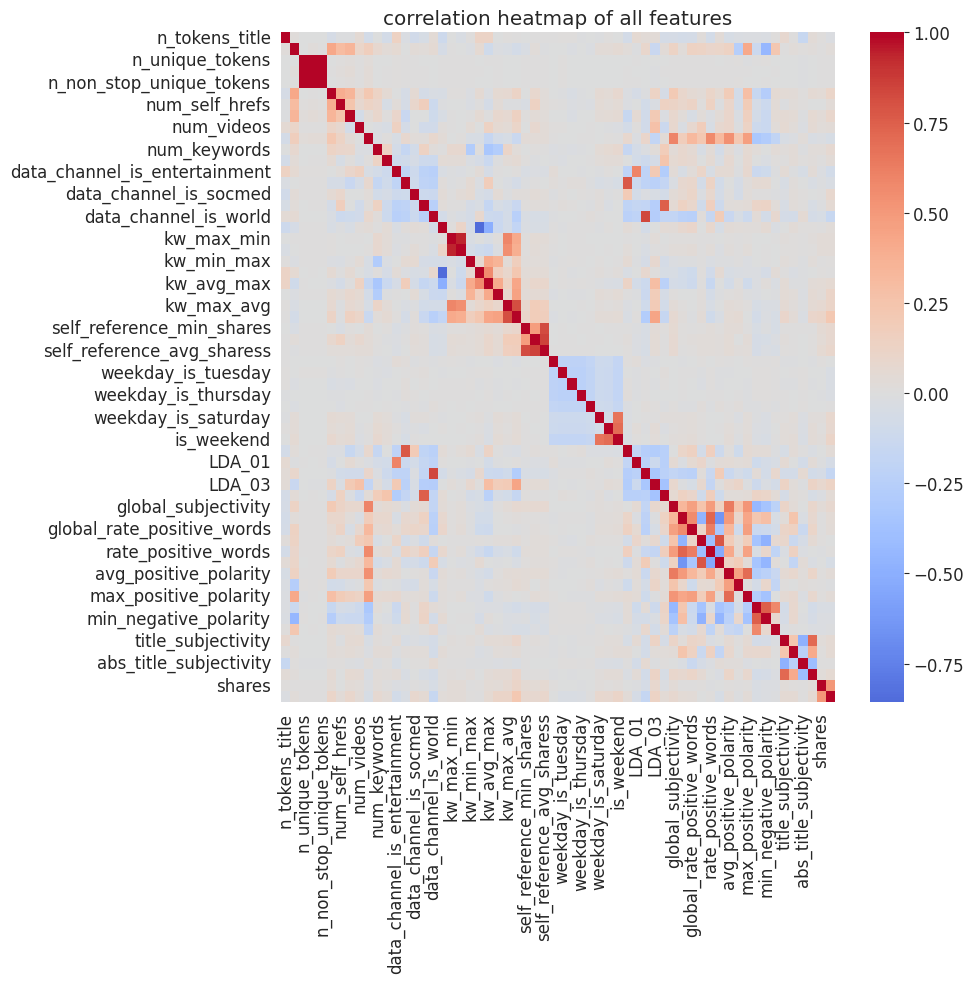

'*center =0 tells the colormap where to place the neutral color (white here)\n-1 -> dark blue (strong negative relation )\n0 ->white (no relation )\n1 ->bold red (strong positive relation )\nwithout center heatmap will use middle as the center .\n*.1f: one dicimal place '

In [38]:
corr_matrix=dataset.corr()
#print(corr_matrix)
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            fmt='.1f')
plt.title('correlation heatmap of all features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()

'''*center =0 tells the colormap where to place the neutral color (white here)
-1 -> dark blue (strong negative relation )
0 ->white (no relation )
1 ->bold red (strong positive relation )
without center heatmap will use middle as the center .
*.1f: one dicimal place '''

#the challenge here is that the features have really weak relation with the target col (shares,log shares )
#we may ensemble columns to get a better correaltion


corr wuth target column(s)

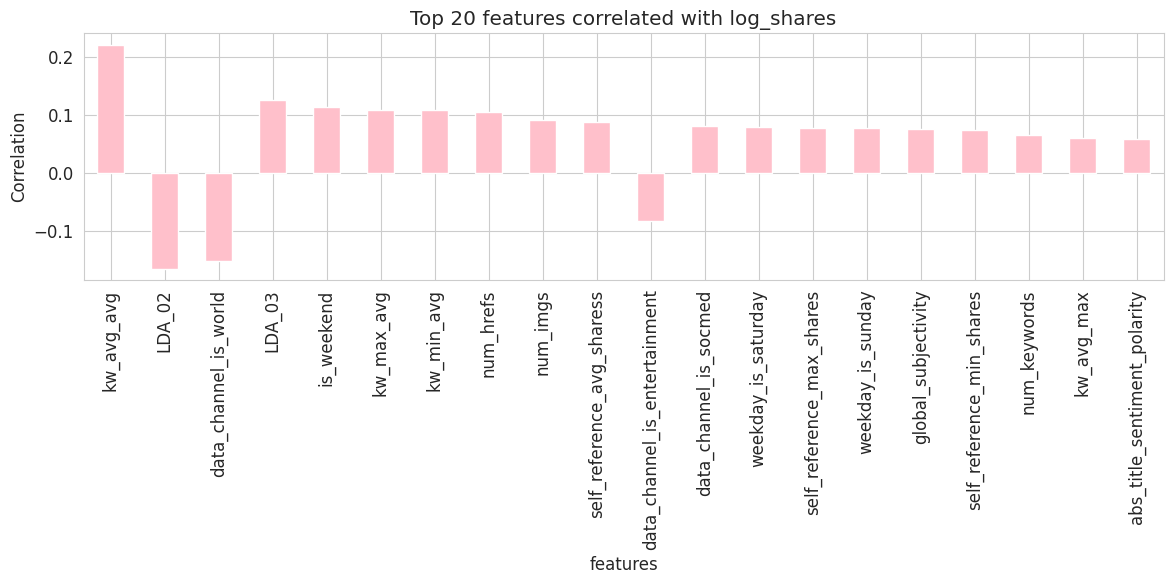

kw_avg_avg                       0.221822
LDA_02                          -0.165076
data_channel_is_world           -0.151685
LDA_03                           0.126037
is_weekend                       0.114391
kw_max_avg                       0.109343
kw_min_avg                       0.108850
num_hrefs                        0.105142
num_imgs                         0.091519
self_reference_avg_sharess       0.087238
data_channel_is_entertainment   -0.082531
data_channel_is_socmed           0.081144
weekday_is_saturday              0.079158
self_reference_max_shares        0.077442
weekday_is_sunday                0.076969
global_subjectivity              0.075174
self_reference_min_shares        0.073374
num_keywords                     0.065945
kw_avg_max                       0.059678
abs_title_sentiment_polarity     0.059191
Name: log_shares, dtype: float64


In [39]:
correlations=dataset.corr()['log_shares'].drop(['log_shares','shares'])
correlations=correlations.reindex(correlations.abs().sort_values(ascending=False).index)

correlations[:20].plot(kind='bar',color='pink', edgecolor='white')
plt.title('Top 20 features correlated with log_shares')
plt.xlabel('features')
plt.ylabel('Correlation')



plt.tight_layout()
plt.savefig('top_20_features_corr.png',dpi=150,bbox_inches='tight')
plt.show()
print(correlations[:20])

day of week effect

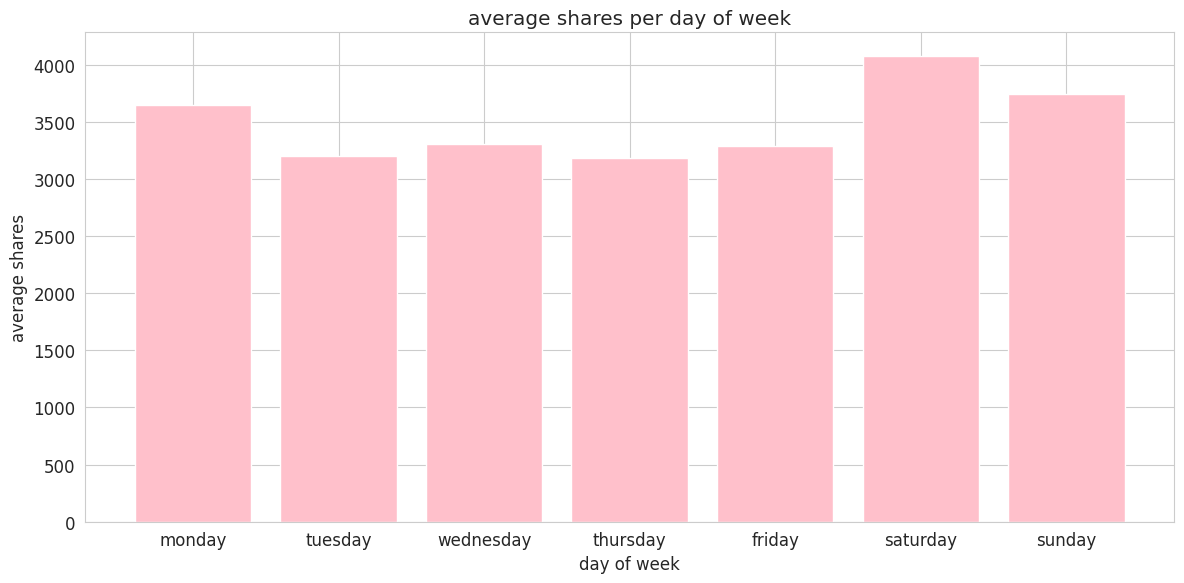

'as we can see sat affects shares the most (gets most shares:~4100)while thursday geta the least~3200'

In [40]:
days=['monday','tuesday','wednesday','thursday','friday','saturday','sunday']

avg_shares_per_day=[]

for day in days:
  col='weekday_is_' +day
  avg=dataset[dataset[col]==1]['shares'].mean()
  avg_shares_per_day.append(avg)
plt.bar(days,avg_shares_per_day,color='pink',edgecolor='white')
plt.title('average shares per day of week')
plt.xlabel('day of week')
plt.ylabel('average shares')
plt.tight_layout()
plt.savefig('avg_shares_per_day.png',dpi=150,bbox_inches='tight')
plt.show()
'''as we can see sat affects shares the most (gets most shares:~4100)while thursday geta the least~3200'''

topic category analysis

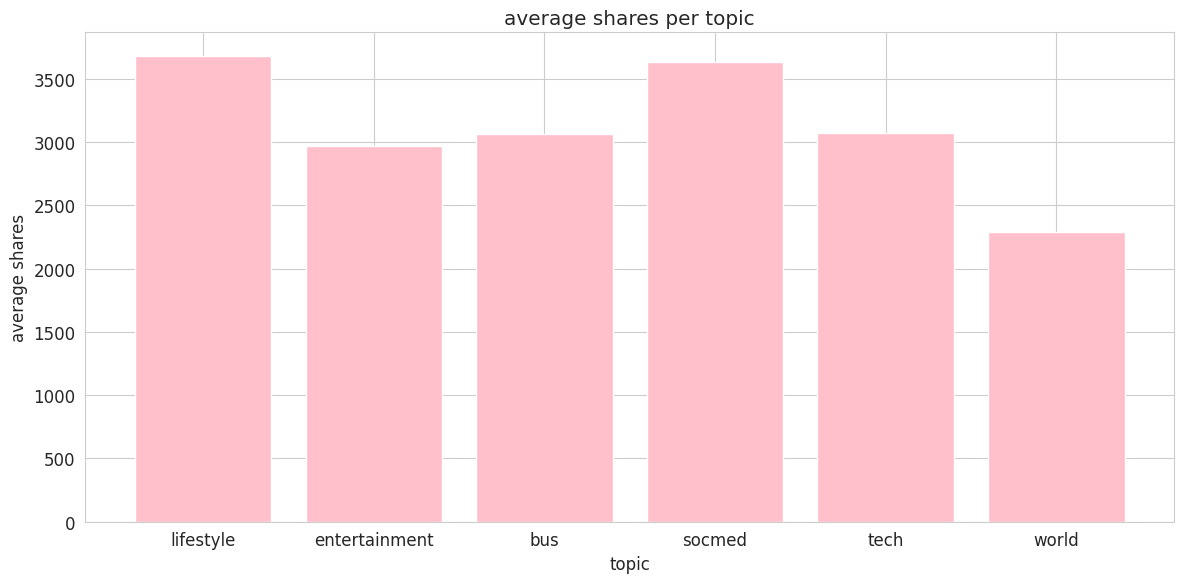

"as not expected:)... tech wasn't really the one with hieghst shares ...in fact lifestyle and socmed were the highest"

In [41]:
#(which type of content performs best on mashable ?)
topics=['lifestyle','entertainment','bus','socmed','tech','world']
avg_shares_per_topic=[]
for topic in topics:
  col='data_channel_is_'+topic
  avg=dataset[dataset[col]==1]['shares'].mean()
  avg_shares_per_topic.append(avg)
plt.bar(topics,avg_shares_per_topic,color='pink',edgecolor='white')
plt.title('average shares per topic')
plt.xlabel('topic')
plt.ylabel('average shares')
plt.tight_layout()
plt.savefig('avg_shares_per_topic.png',dpi=150,bbox_inches='tight')
plt.show()
'''as not expected:)... tech wasn't really the one with hieghst shares ...in fact lifestyle and socmed were the highest'''

sentiment effect on shares

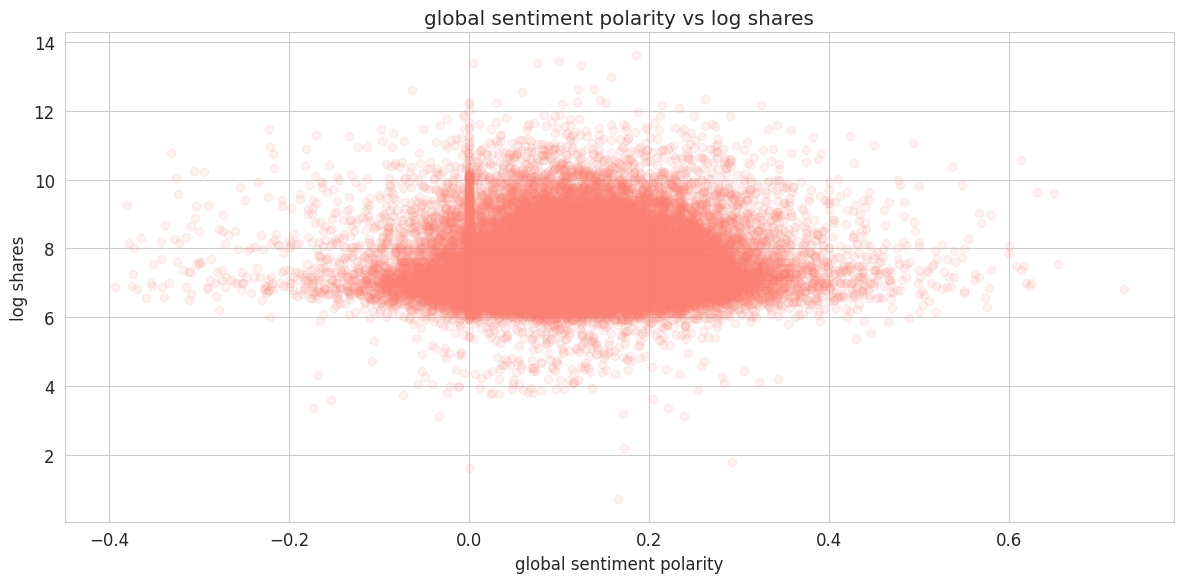

In [42]:
#does the emotional sence of an article affect the # of shares ?
plt.scatter(dataset['global_sentiment_polarity'],
            dataset['log_shares'],
            alpha=0.1,
            color='salmon')
plt.title('global sentiment polarity vs log shares')
plt.xlabel('global sentiment polarity')
plt.ylabel('log shares')
plt.tight_layout()
plt.savefig('sentiment_vs_shares.png', dpi=150, bbox_inches='tight')
plt.show()
#weak relation ...insufficient to predict popularity
# the line at 0.0 at x axis indicates the neutral articles(totally objective )

why i did not choose shares :

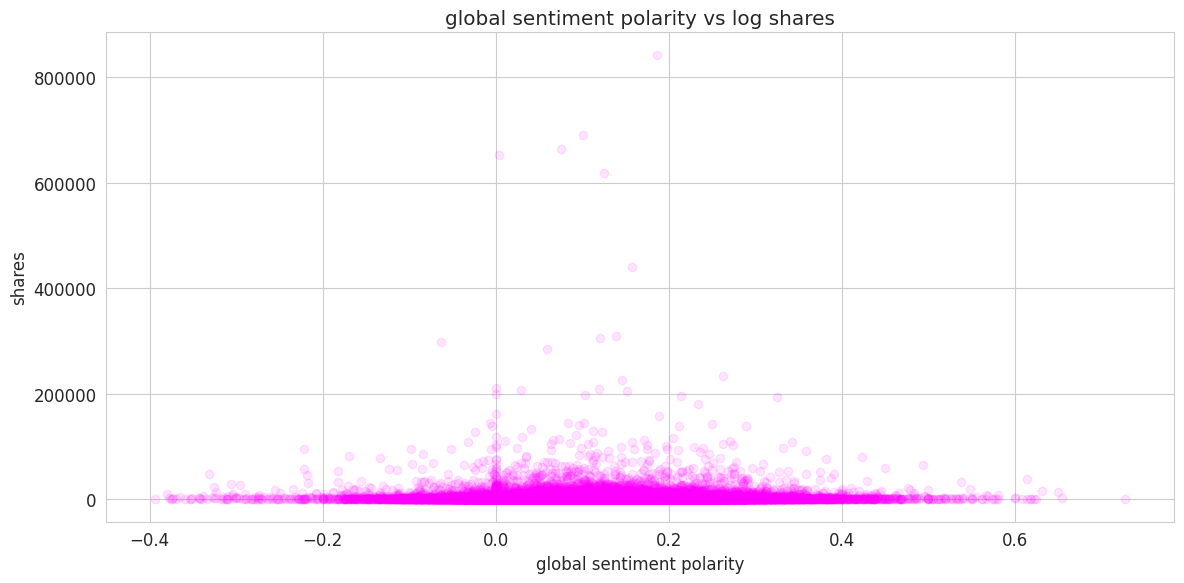

In [43]:
plt.scatter(dataset['global_sentiment_polarity'],
            dataset['shares'],
            alpha=0.1,
            color='magenta')
plt.title('global sentiment polarity vs log shares')
plt.xlabel('global sentiment polarity')
plt.ylabel('shares')
plt.tight_layout()
plt.savefig('sentiment_vs_shares.png', dpi=150, bbox_inches='tight')
plt.show()
#this is why we didn't use shares on y axis :it compressed all noraml articles at the bottom,the outliers r dominating the plot (:

mwdia effect on shares

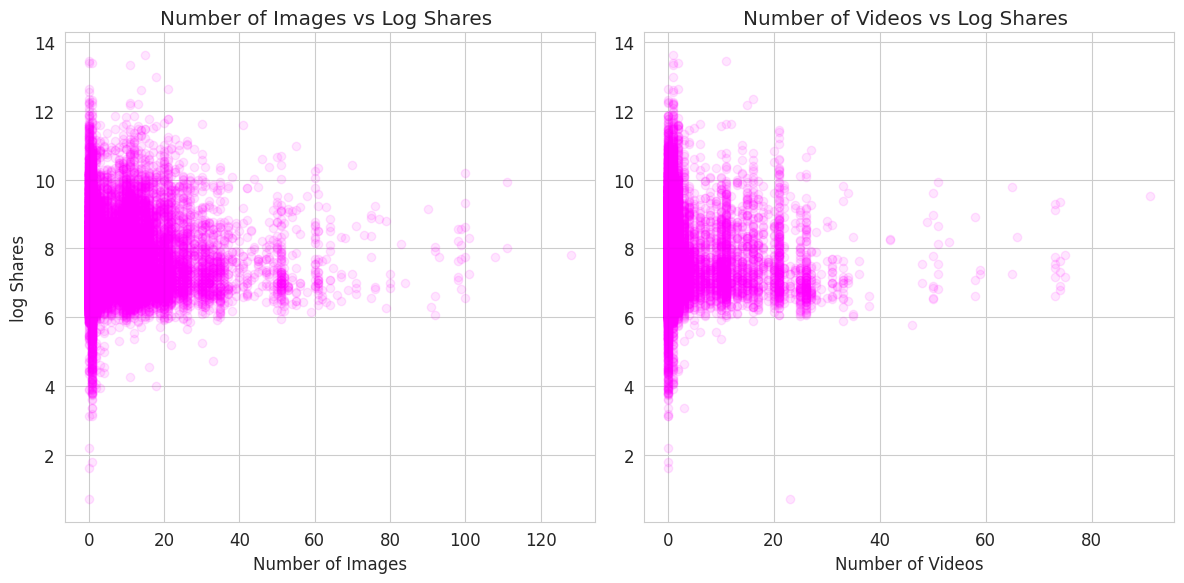

In [44]:
fig, axes = plt.subplots(1,2)

#image:
axes[0].scatter(dataset['num_imgs'],dataset['log_shares'],alpha=0.1 ,color='magenta')
axes[0].set_title("Number of Images vs Log Shares ")
axes[0].set_xlabel("Number of Images")
axes[0].set_ylabel("log Shares")

#videos:
axes[1].scatter(dataset['num_videos'],dataset['log_shares'],alpha=0.1 ,color='magenta')
axes[1].set_title("Number of Videos vs Log Shares ")
axes[1].set_xlabel("Number of Videos")

plt.tight_layout()
plt.savefig('media_vs_shares.png', dpi=150, bbox_inches='tight')
plt.show()


content length effect on shares

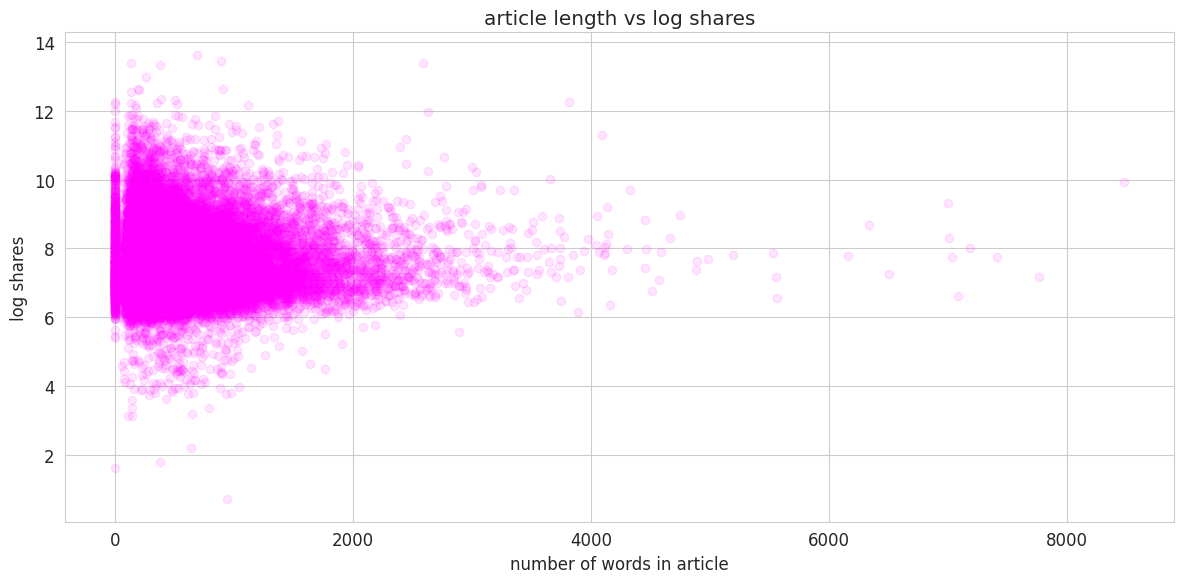

"articls that show zero words ...are probably video only articles,image galleries,or articles where text wasn't captured properly"

In [45]:
plt.scatter(dataset['n_tokens_content'], dataset['log_shares'], alpha=0.1, color='magenta')
plt.title('article length vs log shares')
plt.xlabel('number of words in article')
plt.ylabel('log shares')
plt.tight_layout()
plt.savefig('content_length_vs_shares.png', dpi=150, bbox_inches='tight')
plt.show()
'''articls that show zero words ...are probably video only articles,image galleries,or articles where text wasn't captured properly'''

density plots

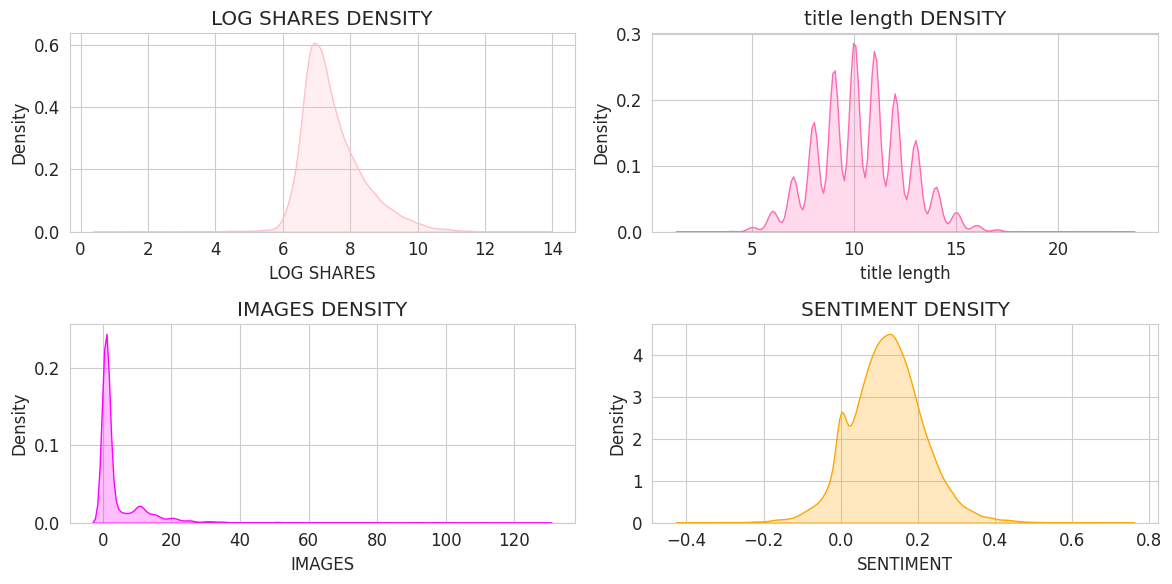

"what do these graphs represent?:\n1)almost bell shaped data :log transformation was the right thing to do.\n2) most articles are short (0-500) word the data is right skewed.\n3) peak is at (0-5)imgs data is also right skewed .\n4) data is almost bell shaped ..peak is at (0.1-0.2). Having a small pumb (little peak)around 0\nmeans that there're two grops of articls exist in this feature..nuetral and almost positive ones"

In [46]:
fig,axes=plt.subplots(2,2)#4 plots
#upper left:
sns.kdeplot(dataset['log_shares'],ax=axes[0,0],color='pink',fill=True)
axes[0,0].set_title('LOG SHARES DENSITY')
axes[0,0].set_xlabel("LOG SHARES")


#upper right
'''sns.kdeplot(dataset['n_tokens_content'],ax=axes[0,1],color="hotpink",fill=True)
axes[0,1].set_title('ARTICLE LENGTH DENSITY')
axes[0,1].set_xlabel("ARTICLE LENGTH")'''

#just tried title length col and felt it's more intresting than article length:
sns.kdeplot(dataset['n_tokens_title'],ax=axes[0,1],color="hotpink",fill=True)
axes[0,1].set_title('title length DENSITY')
axes[0,1].set_xlabel("title length")


#lower left:
sns.kdeplot(dataset['num_imgs'], ax=axes[1,0],color='magenta',fill=True)
axes[1,0].set_title('IMAGES DENSITY')
axes[1,0].set_xlabel("IMAGES")

#lower right:
sns.kdeplot(dataset['global_sentiment_polarity'],ax=axes[1,1],color='orange',fill=True)
axes[1,1].set_title('SENTIMENT DENSITY')
axes[1,1].set_xlabel("SENTIMENT")

plt.tight_layout()
plt.savefig('density_plots.png', dpi=150, bbox_inches='tight')
plt.show()
'''what do these graphs represent?:
1)almost bell shaped data :log transformation was the right thing to do.
2) most articles are short (0-500) word the data is right skewed.
3) peak is at (0-5)imgs data is also right skewed .
4) data is almost bell shaped ..peak is at (0.1-0.2). Having a small pumb (little peak)around 0
means that there're two grops of articls exist in this feature..nuetral and almost positive ones'''


boxplots per category :

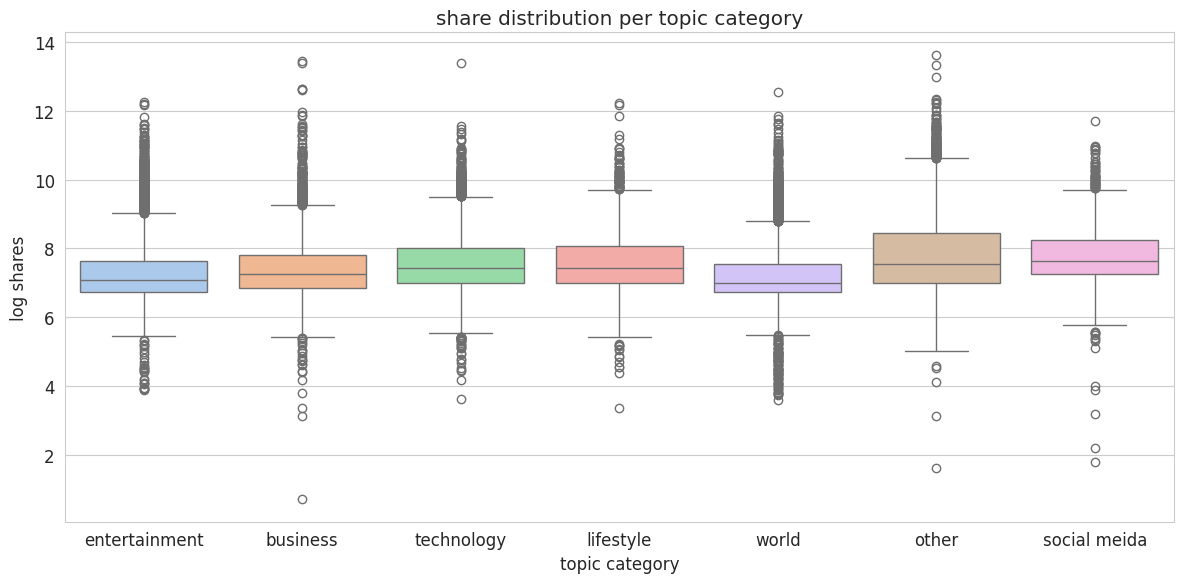

In [47]:
dataset['category']='other'
dataset.loc[dataset['data_channel_is_lifestyle']==1,'category']= 'lifestyle'
dataset.loc[dataset['data_channel_is_entertainment']==1,'category']= 'entertainment'
dataset.loc[dataset['data_channel_is_bus']==1,'category']= 'business'
dataset.loc[dataset['data_channel_is_socmed']==1,'category']= 'social meida'
dataset.loc[dataset['data_channel_is_tech']==1,'category']= 'technology'
dataset.loc[dataset['data_channel_is_world']==1,'category']= 'world'
#created a category column

sns.boxplot(x='category',y='log_shares',data=dataset,palette='pastel')
plt.title('share distribution per topic category')
plt.xlabel('topic category')
plt.ylabel('log shares')
plt.tight_layout()
plt.savefig('share_distribution_per_topic_category.png', dpi=150, bbox_inches='tight')
plt.show()





eda is done ...feature engineering :

In [48]:
#how much of the article is just title ?
dataset['title_word_ratio']=dataset['n_tokens_title']/ (dataset['n_tokens_content']+1)

#image per word:
dataset['img_wrd_ratio']=dataset['num_imgs']/(dataset['n_tokens_content']+1)

#keyword per word:
dataset['keyword_richness']=dataset['num_keywords']/(dataset['n_tokens_content']+1)

#content complexity:unique wrds x avg word length
dataset['content_complexity']=dataset['n_unique_tokens']*dataset['average_token_length']

#sentiment score:
dataset['sentiment_score']=dataset['global_sentiment_polarity']*dataset['global_subjectivity']

#how much does article reference to itself ?
dataset['self_refer_ratio']=dataset['num_self_hrefs']/(dataset['num_hrefs']+1)

#log title:
dataset['log_title_length']=np.log1p(dataset['n_tokens_title'])

#total media :
dataset['total_media']=dataset['num_imgs']+dataset['num_videos']


print("FEATURE ENG DONE (new col were added) ")
print("current shape:",dataset.shape)



'''we prevented (error) div by zero when added +1 .
->title_word_ratio:  clickbait detection.
->img_wrd_ratio : img richness.
->keyword density:  Search engine optimization .yes
->content_complexity : reading difficulty level.
->sentiment score: emotional effect.
->self_refer_ratio : promotion to them selves .
->log_title_length : handled skeweness.
->total_media : media richness.'''

FEATURE ENG DONE (new col were added) 
current shape: (39644, 69)


'we prevented (error) div by zero when added +1 .\n->title_word_ratio:  clickbait detection.\n->img_wrd_ratio : img richness.\n->keyword density:  Search engine optimization .yes\n->content_complexity : reading difficulty level.\n->sentiment score: emotional effect.\n->self_refer_ratio : promotion to them selves .\n->log_title_length : handled skeweness.\n->total_media : media richness.'

splitting data first (fixing the mistake)

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from collections import Counter

# -----------------------------
# 1. Define X and y
# -----------------------------

drop_cols = ['shares', 'log_shares', 'category']
X = dataset.drop(columns=drop_cols, errors='ignore')

# Classification target
median_shares = dataset['shares'].median()
y_clf = (dataset['shares'] > median_shares).astype(int)


print("Median threshold:", median_shares)
print("num of popular articles:", y_clf.sum())
print("num of unpopular articles:", len(y_clf) - y_clf.sum())
print(y_clf.value_counts())


# -----------------------------
# 2. Train/test split first
# -----------------------------

X_train_raw, X_test_raw, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)

Median threshold: 1400.0
num of popular articles: 19562
num of unpopular articles: 20082
shares
0    20082
1    19562
Name: count, dtype: int64
Training shape: (31715, 66)
Testing shape: (7929, 66)


log transformation for some skewed features :

In [50]:
# -----------------------------
# Log-transform skewed positive features
# after train/test split
# -----------------------------

skewed_cols = [
    'img_wrd_ratio',
    'n_unique_tokens',
    'n_non_stop_unique_tokens',
    'content_complexity',
    'title_word_ratio',
    'kw_max_min',
    'keyword_richness',
    'self_reference_min_shares',
    'self_reference_avg_sharess',
    'kw_avg_min'
]

X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()

for col in skewed_cols:
    if col in X_train_raw.columns:
        X_train_raw[col] = np.log1p(X_train_raw[col].clip(lower=0))
        X_test_raw[col] = np.log1p(X_test_raw[col].clip(lower=0))

feature selection using 3 methods :

corr with train only (prevent data leakage ):(m1)

In [51]:
# -----------------------------
# Method 1: Correlation with target
# -----------------------------

train_for_corr = X_train_raw.copy()
train_for_corr['target'] = y_train_clf.values

corr_with_target = train_for_corr.corr()['target'].abs().drop('target')
corr_features = corr_with_target[corr_with_target >= 0.03].index.tolist()

print("Correlation-selected features:", len(corr_features))

Correlation-selected features: 48


RF (m2):

In [52]:
# -----------------------------
# Method 2: Tree-based importance
# -----------------------------

rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

rf_selector.fit(X_train_raw, y_train_clf)

importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_raw.columns
).sort_values(ascending=False)

importance_features = importance[importance >= 0.005].index.tolist()

print("Tree-selected features:", len(importance_features))

Tree-selected features: 56


RFE(m3):

In [53]:
# -----------------------------
# Method 3: RFE
# -----------------------------

rfe_model = LogisticRegression(max_iter=1000, random_state=42)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=20
)

rfe.fit(X_train_raw, y_train_clf)

rfe_features = X_train_raw.columns[rfe.support_].tolist()

print("RFE-selected features:", len(rfe_features))

RFE-selected features: 20


voting (final features selected by at least 2methods):

In [54]:
# -----------------------------
# Voting: keep features selected by at least 2 methods
# -----------------------------

all_features = corr_features + importance_features + rfe_features
feature_counts = Counter(all_features)

final_features = [feature for feature, count in feature_counts.items() if count >= 2]

print("Final selected features:", len(final_features))
print(final_features)

Final selected features: 48
['n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_max_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity', 'title_subjectivity', 'title_sentiment_polarity', 'abs_title_sentiment_polarity', 'content_complexity', 'sentiment_score', 'self_refer_ratio', 'log_title_length', 'total_media', 'img_wrd_ratio', 'min_positive_polarity', 'abs_title_subjectivity

scaling (after feature selection ):

In [55]:
# -----------------------------
# Select final features
# -----------------------------

X_train_selected = X_train_raw[final_features].copy()
X_test_selected = X_test_raw[final_features].copy()

# -----------------------------
# Scale using training data only
# -----------------------------

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

x_train_clf = pd.DataFrame(
    X_train_scaled,
    columns=final_features,
    index=X_train_selected.index
)

x_test_clf = pd.DataFrame(
    X_test_scaled,
    columns=final_features,
    index=X_test_selected.index
)

print("Scaling done")
print("Training shape:", x_train_clf.shape)
print("Testing shape:", x_test_clf.shape)

Scaling done
Training shape: (31715, 48)
Testing shape: (7929, 48)


PCA (dimensionality reduction )


In [56]:
from sklearn.decomposition import PCA

# -----------------------------
# Dimensionality Reduction: PCA
# fit on training data only
# -----------------------------

pca = PCA(n_components=0.95, random_state=42)

x_train_pca = pca.fit_transform(x_train_clf)
x_test_pca = pca.transform(x_test_clf)

print("Original number of features:", x_train_clf.shape[1])
print("Number of PCA components:", x_train_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_.sum())

Original number of features: 48
Number of PCA components: 1
Explained variance ratio: 0.9999999708086071


to compare all model's results:

In [57]:
results=[]

trying the pca effect on a linear model :(to compare)

PCA Logistic Regression Results
Accuracy: 0.5217555807794173
              precision    recall  f1-score   support

           0       0.52      0.88      0.65      4017
           1       0.56      0.15      0.24      3912

    accuracy                           0.52      7929
   macro avg       0.54      0.52      0.44      7929
weighted avg       0.54      0.52      0.45      7929

Training Accuracy: 0.525082768406117
Testing Accuracy: 0.5217555807794173

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.52      0.88      0.65      4017
     Popular       0.56      0.15      0.24      3912

    accuracy                           0.52      7929
   macro avg       0.54      0.52      0.44      7929
weighted avg       0.54      0.52      0.45      7929



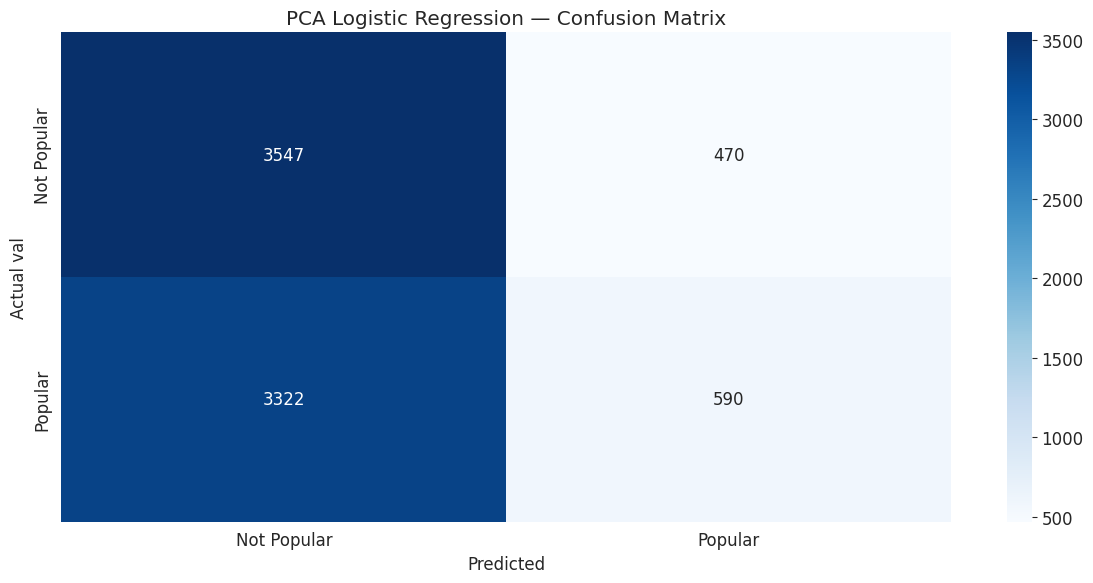

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_pca = LogisticRegression(max_iter=1000, random_state=42)
lr_pca.fit(x_train_pca, y_train_clf)

y_pred_pca = lr_pca.predict(x_test_pca)
y_prob_pca = lr_pca.predict_proba(x_test_pca)[:, 1]

print("PCA Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_pca))

print(classification_report(y_test_clf, y_pred_pca))

Training_Accuracy= lr_pca.score(x_train_pca, y_train_clf)
Testing_Accuracy= lr_pca.score(x_test_pca, y_test_clf)
print("Training Accuracy:",Training_Accuracy )
print("Testing Accuracy:",Testing_Accuracy)
print()

print("Detailed Report:")
print(classification_report(y_test_clf, y_pred_pca,
      target_names=['Not Popular', 'Popular']))

# Clean confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_pca)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('PCA Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual val')
plt.tight_layout()
plt.show()

results.append({

                "model":"PCA Logistic Regression",
    "train acc" :Training_Accuracy,
    "test acc" :Testing_Accuracy

})

#didn't really help...underfitting
#If I compress my selected features into PCA components, does Logistic Regression perform better, worse, or about the same?

logistic regression (1st clf model)

Training Accuracy: 0.6365126911556046
Testing Accuracy: 0.6343801235969226

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.64      0.64      0.64      4017
     Popular       0.63      0.62      0.63      3912

    accuracy                           0.63      7929
   macro avg       0.63      0.63      0.63      7929
weighted avg       0.63      0.63      0.63      7929



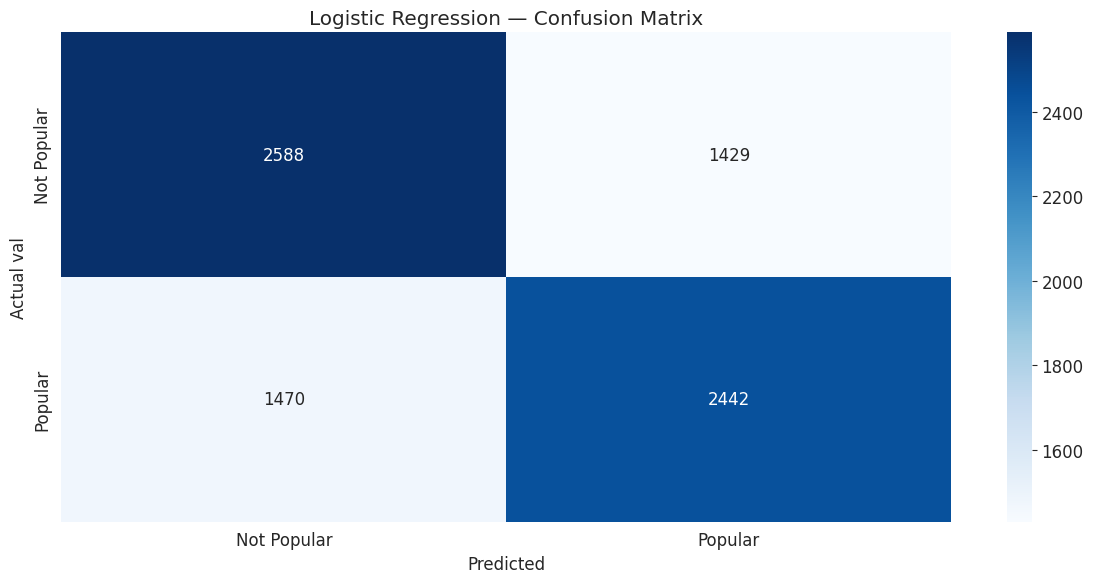

In [60]:
#reminder:logreg calculates the 'probability ' of the article being popular (0-1),0.5 is it's threshold(default)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and predict
lr = LogisticRegression(random_state=42, max_iter=1000)
#default maxiter is 100 ..too low (max # of attempts to find perfect wieght)
lr.fit(x_train_clf, y_train_clf)
y_pred_lr = lr.predict(x_test_clf)



Training_Accuracy= lr.score(x_train_clf, y_train_clf)
Testing_Accuracy= lr.score(x_test_clf, y_test_clf)
print("Training Accuracy:",Training_Accuracy )
print("Testing Accuracy:",Testing_Accuracy)
print()
print("Detailed Report:")
print(classification_report(y_test_clf, y_pred_lr,
      target_names=['Not Popular', 'Popular']))

# Clean confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual val')
plt.tight_layout()
plt.show()
#lowest accuracy so far:this tells that data is not linearly separable.
#no overfitting .


#annot stands for annotation..it tells seaborn to write the values inside each cell.
#fmt=d to only display numbers in integer form .

results.append({
    "model":"logestic regression",
    "train acc" :Training_Accuracy,
    "test acc" :Testing_Accuracy

})


knn(2nd clf model)

chosen k: 15
best accuracy: 0.6247950561230925


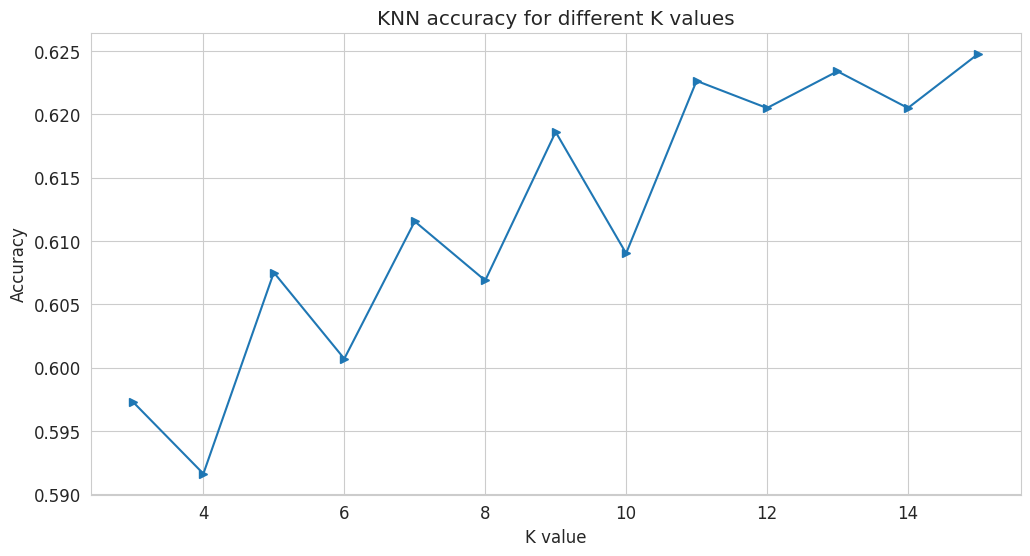

------------------------------------------------------------------------------------------
training accuracy: 0.6799306321929687
testing accuracy: 0.6247950561230925

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.62      0.66      0.64      4017
     Popular       0.63      0.59      0.61      3912

    accuracy                           0.62      7929
   macro avg       0.63      0.62      0.62      7929
weighted avg       0.62      0.62      0.62      7929



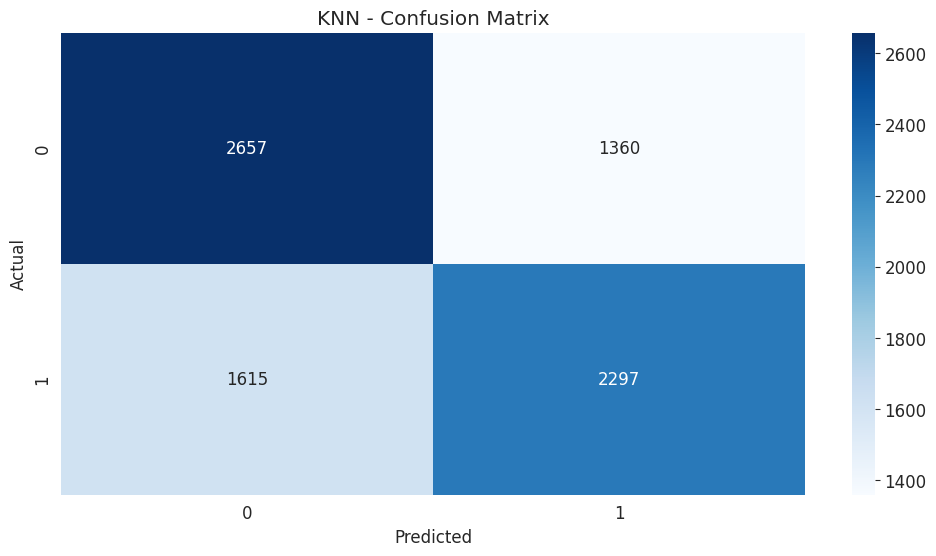

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# save accuracies
accuracies = []

# try different k values
k_values = range(3, 16)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(x_train_clf, y_train_clf)

    accuracy = knn_temp.score(x_test_clf, y_test_clf)
    accuracies.append(accuracy)

# best accuracy -> best k
best_k = list(k_values)[accuracies.index(max(accuracies))]

print("chosen k:", best_k)
print("best accuracy:", max(accuracies))

# visualization
plt.plot(k_values, accuracies, marker='>')
plt.title("KNN accuracy for different K values")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

print('-' * 90)

# ------------------------------------------------
# FIX: train final KNN using the best K
# ------------------------------------------------

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train_clf, y_train_clf)

y_pred_knn = knn.predict(x_test_clf)

training_accuracy = knn.score(x_train_clf, y_train_clf)
testing_accuracy = knn.score(x_test_clf, y_test_clf)

print("training accuracy:", training_accuracy)
print("testing accuracy:", testing_accuracy)
print()

print("Detailed Report:")
print(classification_report(
    y_test_clf,
    y_pred_knn,
    target_names=['Not Popular', 'Popular']
))

# confusion matrix
confmat = confusion_matrix(y_test_clf, y_pred_knn)

sns.heatmap(confmat, annot=True, fmt='d', cmap='Blues')
plt.title('KNN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


results.append({
    "model": "KNN",
    "train acc": training_accuracy,
    "test acc": testing_accuracy

})

decision tree(classification):

train acc: 0.6460349992117295
testing acc: 0.6314793794930004

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.64      0.64      0.64      4017
     Popular       0.63      0.62      0.63      3912

    accuracy                           0.63      7929
   macro avg       0.63      0.63      0.63      7929
weighted avg       0.63      0.63      0.63      7929



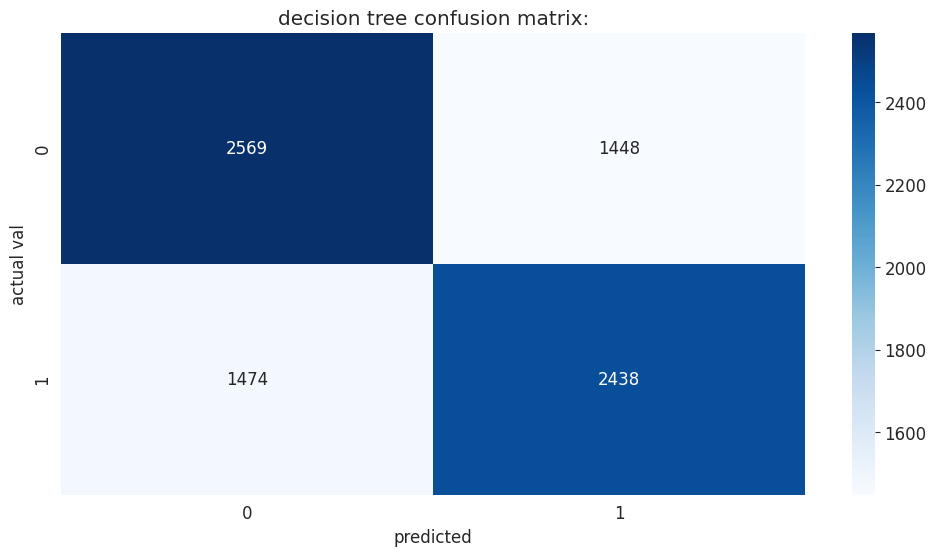

In [62]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(x_train_clf,y_train_clf)
y_pred_dt=dt.predict(x_test_clf)


train_acc=dt.score(x_train_clf,y_train_clf)
test_acc=dt.score(x_test_clf,y_test_clf)
print("train acc:",train_acc)
print("testing acc:",test_acc)
print()
print("Detailed Report:")
print(classification_report(y_test_clf, y_pred_dt,
      target_names=['Not Popular', 'Popular']))

confmat=confusion_matrix(y_test_clf,y_pred_dt)
sns.heatmap(confmat,annot=True,fmt='d',cmap="Blues")
plt.title("decision tree confusion matrix:")
plt.xlabel("predicted")
plt.ylabel("actual val")
plt.show()




results.append({
    "model":"decision tree",
    "train acc":train_acc,
    "test acc":test_acc
})

random forest

training acc: 0.7630774081664827
testing acc: 0.6651532349602725

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.67      0.67      0.67      4017
     Popular       0.66      0.66      0.66      3912

    accuracy                           0.67      7929
   macro avg       0.67      0.67      0.67      7929
weighted avg       0.67      0.67      0.67      7929



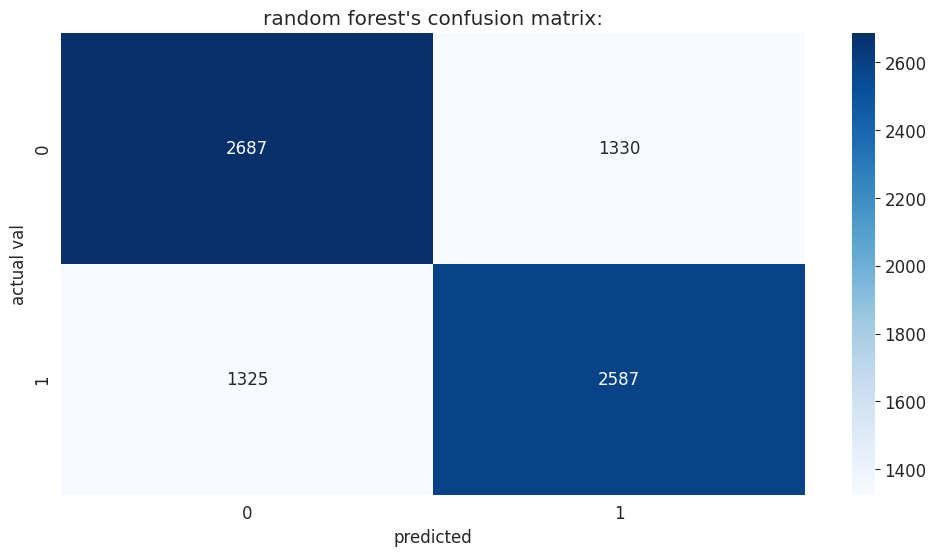

In [63]:
from sklearn .ensemble import RandomForestClassifier
rf_clf=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10)
rf_clf.fit(x_train_clf,y_train_clf)
y_pred_rf=rf_clf.predict(x_test_clf)

training_acc=rf_clf.score(x_train_clf,y_train_clf)
testing_acc=rf_clf.score(x_test_clf,y_test_clf)
print("training acc:",training_acc)
print("testing acc:",testing_acc)
print()
print("Detailed Report:")
print(classification_report(y_test_clf, y_pred_rf,
      target_names=['Not Popular', 'Popular']))

confmat=confusion_matrix(y_test_clf,y_pred_rf)
sns.heatmap(confmat,annot=True,fmt='d',cmap="Blues")
plt.title("random forest's confusion matrix:")
plt.xlabel("predicted")
plt.ylabel("actual val")
plt.show()

results.append({
    "model":"random forest",
    "train acc":training_acc,
    "test acc":testing_acc
})


i tried grid search but it didn't really make a change or improve the score so i deleted it (running time became extremly long)



randomized search

Best parameters {'max_depth': 12, 'min_samples_split': 7, 'n_estimators': 102}
Best cv accuracy: 0.6649221792800949
train acc:  0.8234274002837774
test acc:  0.665531592886871

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.67      0.67      0.67      4017
     Popular       0.66      0.66      0.66      3912

    accuracy                           0.67      7929
   macro avg       0.67      0.67      0.67      7929
weighted avg       0.67      0.67      0.67      7929



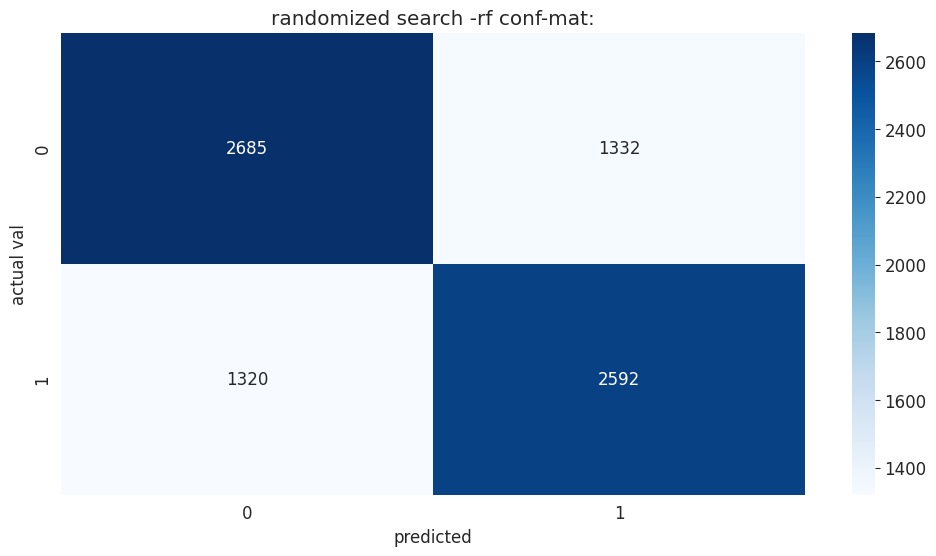

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist={
    'n_estimators':randint(50,300),
    #n of trees
    'max_depth':randint(5,20),
    'min_samples_split':randint(2,15)
}
random_search=RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
random_search.fit(x_train_clf,y_train_clf)
print("Best parameters",random_search.best_params_)
print("Best cv accuracy:",random_search.best_score_)

train_acc=random_search.best_estimator_.score(x_train_clf,y_train_clf)
test_acc=random_search.best_estimator_.score(x_test_clf,y_test_clf)
print("train acc: ",train_acc)
print("test acc: ",test_acc)
print()
print("Detailed Report:")
best_rf = random_search.best_estimator_
y_pred_random_rf = best_rf.predict(x_test_clf)

print(classification_report(y_test_clf, y_pred_random_rf,
      target_names=['Not Popular', 'Popular']))

confmat = confusion_matrix(y_test_clf, y_pred_random_rf)
sns.heatmap(confmat,annot=True,fmt='d',cmap="Blues")
plt.title("randomized search -rf conf-mat:")
plt.xlabel("predicted")
plt.ylabel("actual val")
plt.show()


results.append({
    "model":"randomized search rf",
    "train acc":train_acc,
    "test acc":test_acc
})

choosing best model out of (random search,randomized for rf)

In [65]:
basic_rf_acc = rf_clf.score(x_test_clf, y_test_clf)
#grid_acc=grid_search.best_estimator_.score(x_test_clf,y_test_clf)
random_acc=random_search.best_estimator_.score(x_test_clf,y_test_clf)

print("Basic RF test accuracy:",basic_rf_acc)
#print("grid search tst acc:",grid_acc)
print("randomized search tst acc:",random_acc)

#best_acc=max(basic_rf_acc,grid_acc,random_acc)
best_acc=max(basic_rf_acc,random_acc)

if best_acc==random_acc:
  best_rf=random_search.best_estimator_
else:
  best_rf=rf_clf
print("best model: ",best_rf)
print("best rf acc: ",best_acc)


# if best_acc==basic_rf_acc:
#   best_rf=rf_clf
# elif best_acc==grid_acc:
#   best_rf=grid_search.best_estimator_
# else:
#   best_rf=random_search.best_estimator_
# print("best model: ",best_rf)
# print("best rf acc: ",best_acc)

#removed grid search ...running time is unbelievable

Basic RF test accuracy: 0.6651532349602725
randomized search tst acc: 0.665531592886871
best model:  RandomForestClassifier(max_depth=12, min_samples_split=7, n_estimators=102,
                       random_state=42)
best rf acc:  0.665531592886871


svm:(rbf kernel)..but with samples

train acc: 0.5248
test acc: 0.5215033421616849

classification report:               precision    recall  f1-score   support

 not_popular       0.52      0.88      0.65      4017
     popular       0.56      0.15      0.24      3912

    accuracy                           0.52      7929
   macro avg       0.54      0.52      0.44      7929
weighted avg       0.54      0.52      0.45      7929



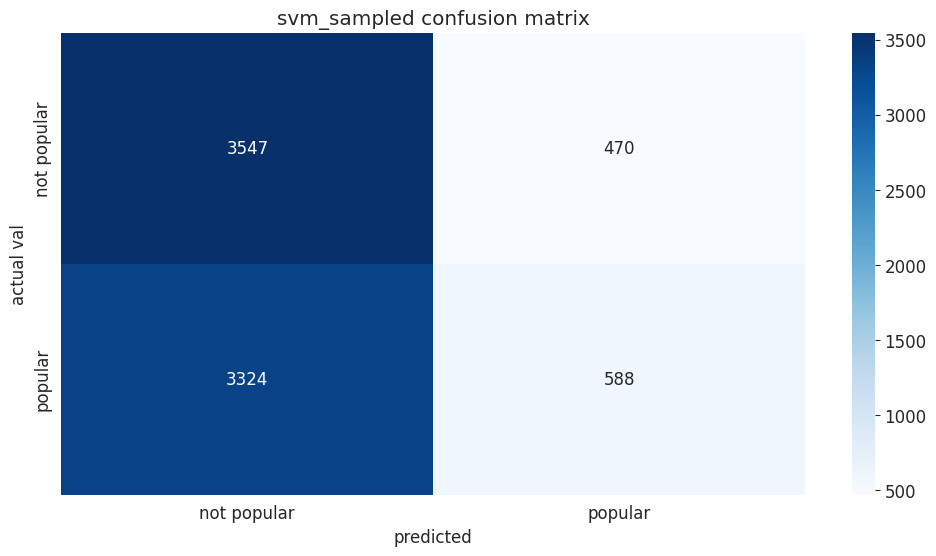

In [66]:
from sklearn.svm import SVC
# from sklearn.utils  import resample
# x_sample,y_sample=resample(x_train_clf,y_train_clf,
#                            n_samples=6000,random_state=42)
#using stratification instead of only small sampels to try to fix the underfitting result.

from sklearn.model_selection import train_test_split
x_sample,_,y_sample,_=train_test_split(x_train_clf,y_train_clf,
                                       train_size=10000,stratify=y_train_clf,random_state=42)#to ensure balanced classes/:

svm_sampled=SVC(kernel='rbf',cache_size=1000,C=10,gamma='scale',random_state=42,probability =True)
#sample 5000-8000 instead of 100000.
svm_sampled.fit(x_sample,y_sample)
y_pred_svm2=svm_sampled.predict(x_test_clf)

train_acc=svm_sampled.score(x_sample,y_sample)
test_acc=svm_sampled.score(x_test_clf,y_test_clf)
print("train acc:",train_acc)
print("test acc:",test_acc)
print()
print("classification report:",
      classification_report(y_test_clf,y_pred_svm2,
      target_names=['not_popular','popular']))

confmat=confusion_matrix(y_test_clf,y_pred_svm2)
sns.heatmap(confmat,annot=True, fmt='d',cmap="Blues",
            xticklabels=['not popular','popular'],
            yticklabels=['not popular','popular'])
plt.title('svm_sampled confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual val')
plt.show()
results.append({
    "model":"SVC rbf sampled",
    "train acc":train_acc,
    "test acc":test_acc
})
#tried the samples solution as suggested ..didn't realy decrease the running time significantly ,the score didn't drop or change:(0.50,0.51).(underfitting)

linear svc

TRAINING ACC: 0.6255399653160965
TESTING ACC: 0.6218943120191701

              precision    recall  f1-score   support

 Not Popular       0.63      0.63      0.63      4017
     Popular       0.62      0.61      0.62      3912

    accuracy                           0.62      7929
   macro avg       0.62      0.62      0.62      7929
weighted avg       0.62      0.62      0.62      7929



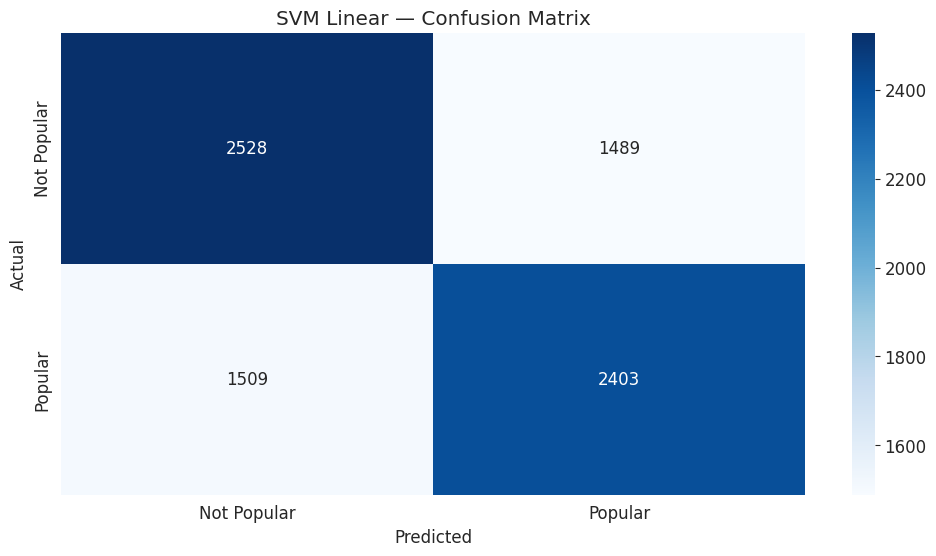

In [67]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

#used this because linearsvc is way faster than svc(kernel='linear)
svm_linear=CalibratedClassifierCV(LinearSVC(C=0.1,max_iter=2000,random_state=42))
# CalibratedClassifierCV wrapper is needed because LinearSVC has no predict_proba (needed for ROC later)

svm_linear.fit(x_train_clf,y_train_clf)
#this method is supposed to be fast enough on full data(no sampling ).
y_pred_svm_lin=svm_linear.predict(x_test_clf)
train_acc = svm_linear.score(x_train_clf, y_train_clf)
test_acc = svm_linear.score(x_test_clf, y_test_clf)

print("TRAINING ACC:", train_acc)
print("TESTING ACC:", test_acc)
print()
print(classification_report(y_test_clf, y_pred_svm_lin,
      target_names=['Not Popular', 'Popular']))

cm = confusion_matrix(y_test_clf, y_pred_svm_lin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('SVM Linear — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results.append({
    "model": "SVC linear",
    "train acc": train_acc,
    "test acc": test_acc
})


XGBoost:(extreme gradient boosting)

train acc: 0.6818540122970204
test acc: 0.6659099508134695

classification report:               precision    recall  f1-score   support

 Not Popular       0.67      0.68      0.67      4017
     Popular       0.66      0.65      0.66      3912

    accuracy                           0.67      7929
   macro avg       0.67      0.67      0.67      7929
weighted avg       0.67      0.67      0.67      7929



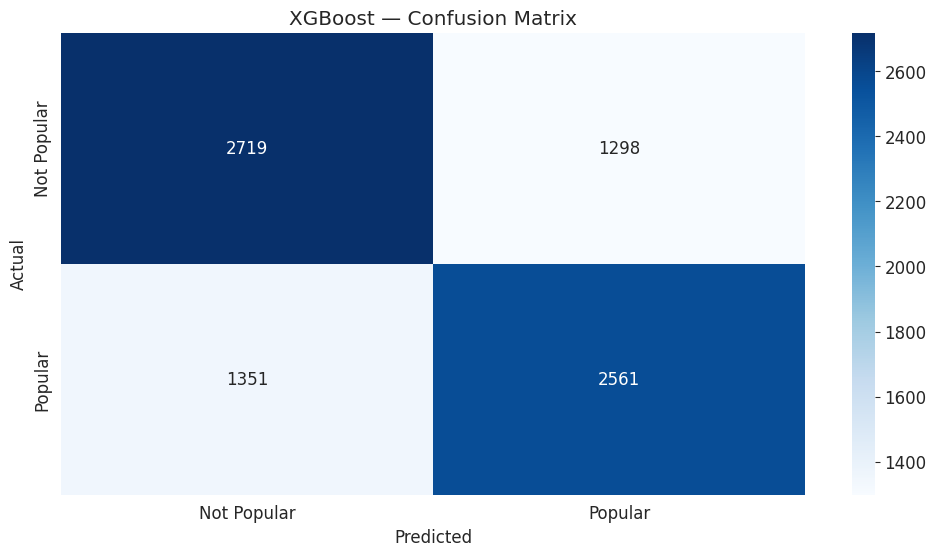

In [68]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=100,max_depth=3,
                  learning_rate=0.1,tree_method='hist',random_state=42,n_jobs=-1,
                  eval_metric='logloss')
#learning rate=how much each new tree contributes,smaller->better generalization .
#eval_metric=uesd during training ,how wrong predicted probabilities are ,smaller->better .
#
xgb.fit(x_train_clf,y_train_clf)
y_pred_xgb=xgb.predict(x_test_clf)

train_acc=xgb.score(x_train_clf,y_train_clf)
test_acc=xgb.score(x_test_clf,y_test_clf)
print("train acc:",train_acc)
print("test acc:",test_acc)
print()
print("classification report:",classification_report(y_test_clf,y_pred_xgb,
                              target_names=['Not Popular', 'Popular']))
conmat=confusion_matrix(y_test_clf,y_pred_xgb)
sns.heatmap(conmat,annot=True,fmt='d',cmap="Blues",
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('XGBoost — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results.append({
    "model":"XGBoost",
    "train acc":train_acc,
    "test acc":test_acc
})

ROC curve

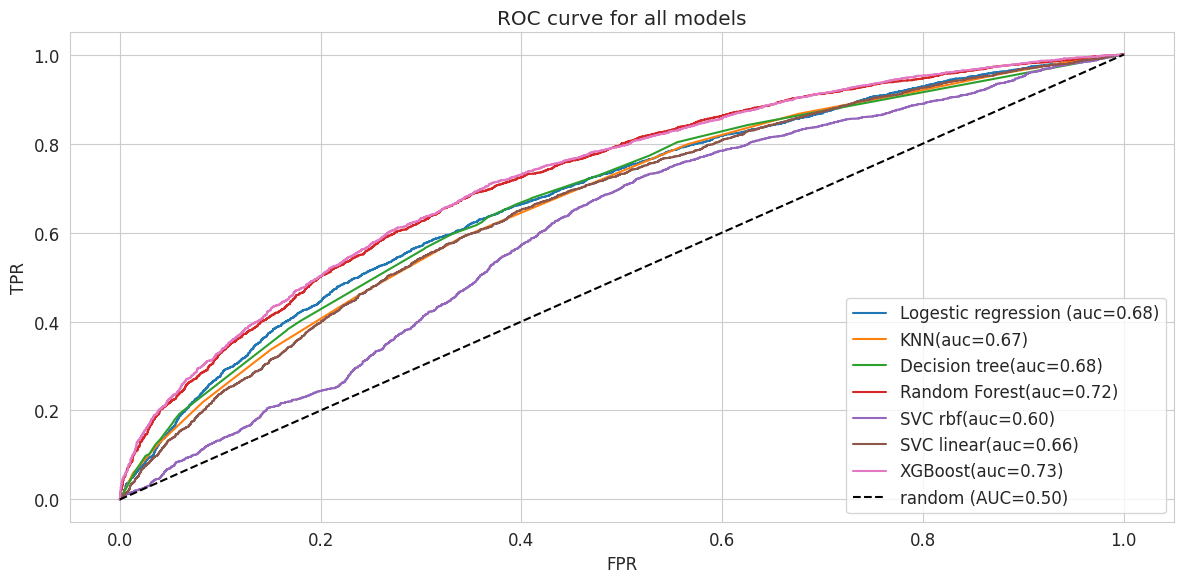

In [69]:
from re import L
from sklearn.metrics import roc_curve ,auc
models={
    "Logestic regression ":lr,
    "KNN":knn,
    "Decision tree":dt,
    "Random Forest":best_rf,
    "SVC rbf":svm_sampled,
    "SVC linear":svm_linear,
    "XGBoost":xgb
}
#plotting roc for eacg model:
for name ,model in models.items():
  #probability prediction:
   y_proba=model.predict_proba(x_test_clf)[:,1]
  #instead of 0,1 ...we want a probability ,[:,1]-> to only get the popular class for roc .(so roc can test every possible threshold)

  #calculating roc curve points
   fpr,tpr,_=roc_curve(y_test_clf,y_proba)
  #calculates auc:
   roc_auc=auc(fpr,tpr)
   plt.plot(fpr,tpr,label=f"{name}(auc={roc_auc:.2f})")
  #any model above this line is better than random guessing :(this represents the random guessing )
plt.plot([0,1],[0,1],'k--',label='random (AUC=0.50)')

plt.title('ROC curve for all models')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()






In [70]:
#the results dataframe (to compare outputs ):
results_df=pd.DataFrame(results)
print(results_df)

                     model  train acc  test acc
0  PCA Logistic Regression   0.525083  0.521756
1      logestic regression   0.636513  0.634380
2                      KNN   0.679931  0.624795
3            decision tree   0.646035  0.631479
4            random forest   0.763077  0.665153
5     randomized search rf   0.823427  0.665532
6          SVC rbf sampled   0.524800  0.521503
7               SVC linear   0.625540  0.621894
8                  XGBoost   0.681854  0.665910


precision recall-curve

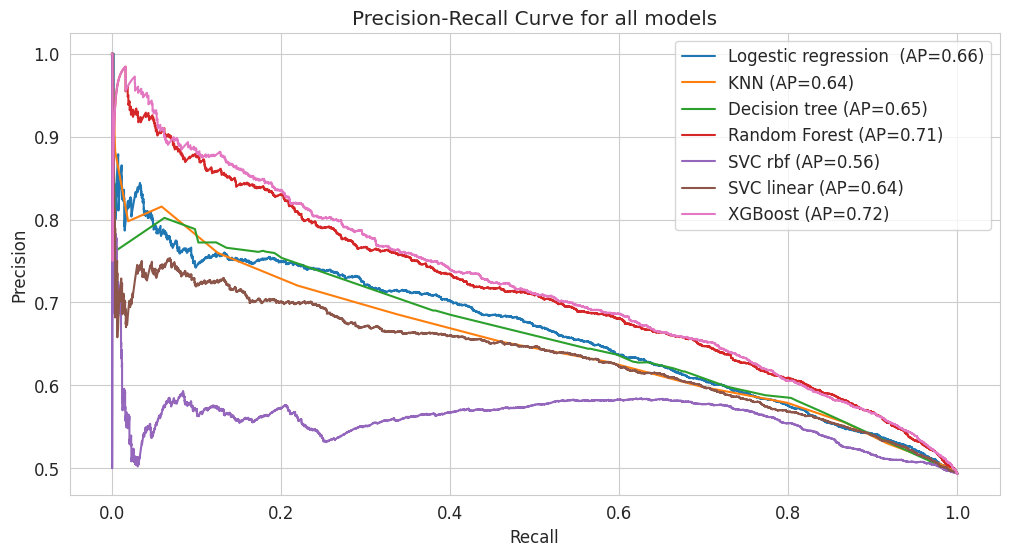

"precision :When I say it's popular, how often am I right?\nrecall:Of all truly popular articles, how many did I find?\n\nSimple example — 100 popular articles exist, your model flags 80 as popular:\n60 of those 80 are actually popular → Precision = 60/80 = 75%\nbut you missed 40 real ones → Recall = 60/100 = 60%"

In [71]:
from sklearn.metrics import precision_recall_curve,average_precision_score

models_proba={
      "Logestic regression ":(lr,x_test_clf),
    "KNN":(knn,x_test_clf),
    "Decision tree":(dt,x_test_clf),
    "Random Forest":(best_rf,x_test_clf),
    "SVC rbf":(svm_sampled,x_test_clf),
    "SVC linear":(svm_linear,x_test_clf),
    "XGBoost":(xgb,x_test_clf)

}
for name,(model,x_test) in models_proba.items():
  proba=model.predict_proba(x_test_clf)[:,1]
  #shows probability of predicting popular .
  precision,recall,_=precision_recall_curve(y_test_clf,proba)
  #tests every possible threshold &calculates precesion and recall at each .
  average_precision=average_precision_score(y_test_clf,proba)
  #summarize each model's curve into whole number ...higher better .
  plt.plot(recall,precision,label=f"{name} (AP={average_precision:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for all models")
plt.legend(loc="upper right")
plt.show()

#remember :
'''precision :When I say it's popular, how often am I right?
recall:Of all truly popular articles, how many did I find?

Simple example — 100 popular articles exist, your model flags 80 as popular:
60 of those 80 are actually popular → Precision = 60/80 = 75%
but you missed 40 real ones → Recall = 60/100 = 60%'''

calibration curve :معايرة

Logestic regression  Brier Score: 0.2253
KNN Brier Score: 0.2320
Decision tree Brier Score: 0.2258
Random Forest Brier Score: 0.2131
SVC rbf Brier Score: 0.2494
SVC linear Brier Score: 0.2305
XGBoost Brier Score: 0.2112


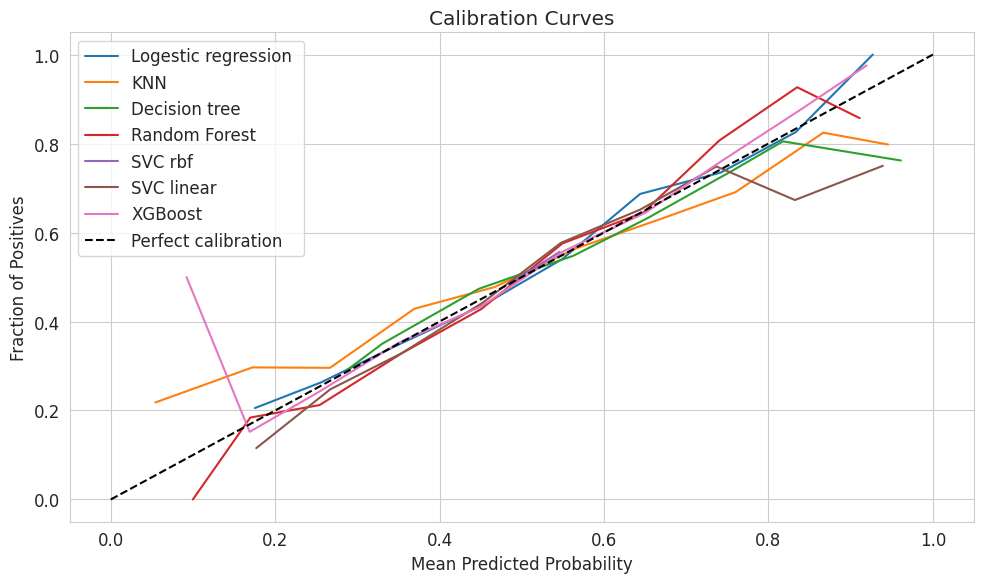

In [72]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

plt.figure(figsize=(10, 6))

for name, (model, x_test) in models_proba.items():
    proba = model.predict_proba(x_test_clf)[:, 1]
    #splits predictions into 10 groups,for each group checks:when the model predicted ~70% probability, were actually 70% of those articles popular? If yes → well calibrated
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test_clf, proba, n_bins=10)

    plt.plot(mean_predicted_value, fraction_of_positives, label=name)

    bs = brier_score_loss(y_test_clf, proba)
    #almost :average squared error between predicted probability and actual outcome.(lower= better),perfect model = 0, random guessing ≈ 0.25.
    #xgboost has the least brier score of them (confirms my choice of it as the best clf model)
    print(f"{name} Brier Score: {bs:.4f}")

plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
#plts the diagonal dashed line (perfect calibration)
plt.title('Calibration Curves')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

learning curves

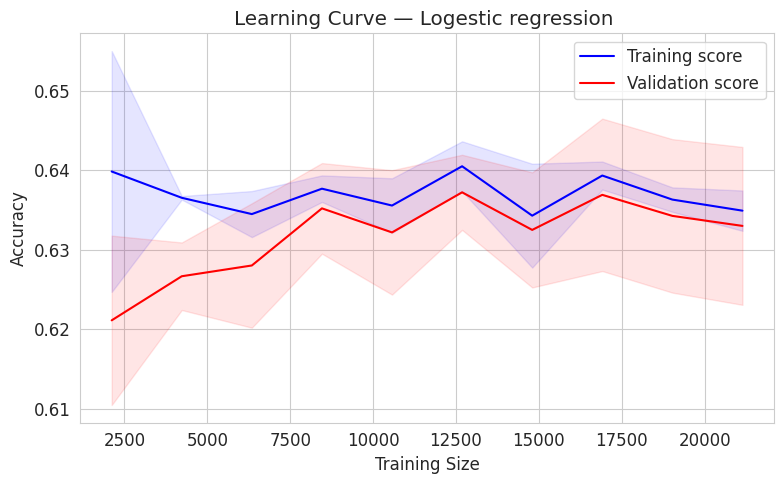

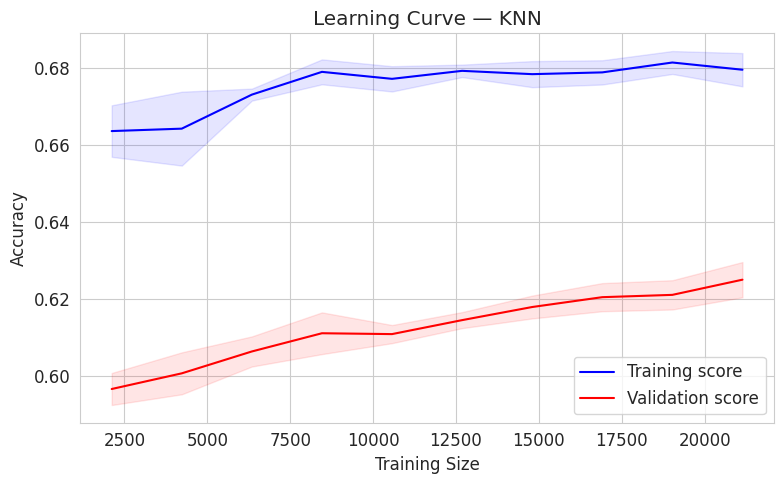

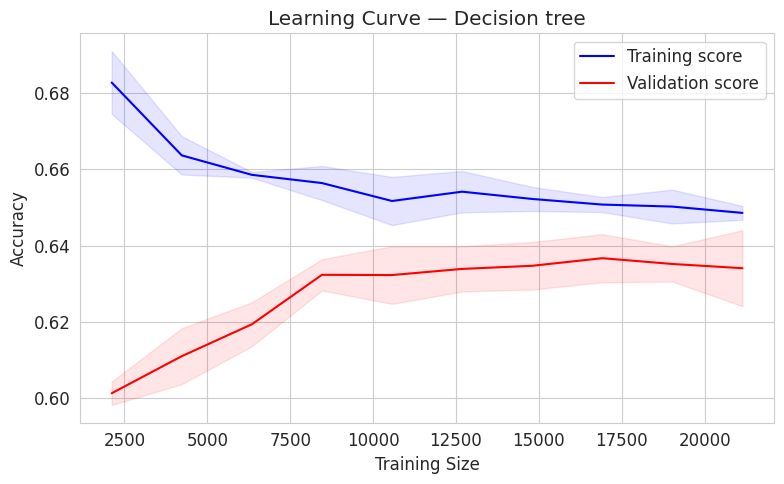

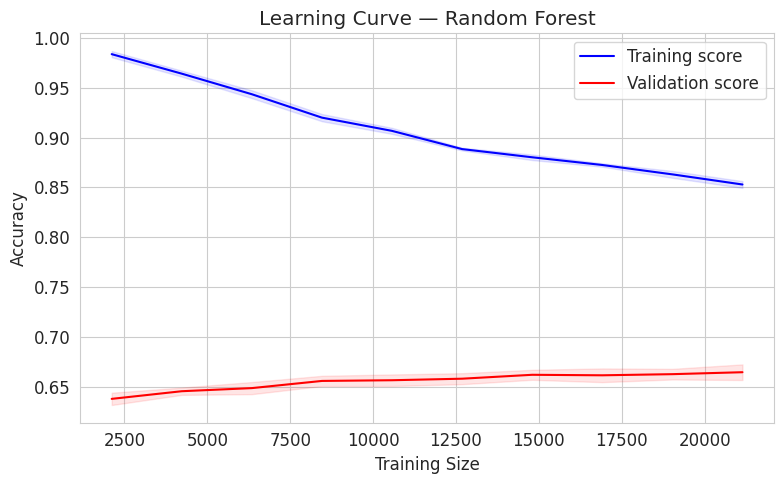

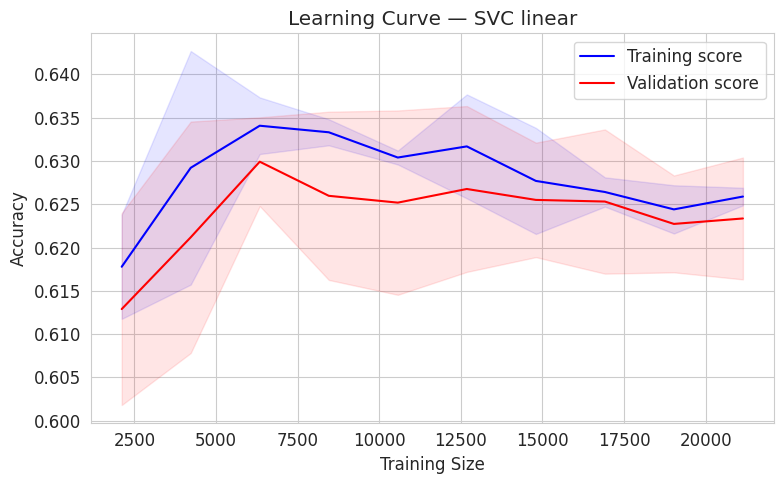

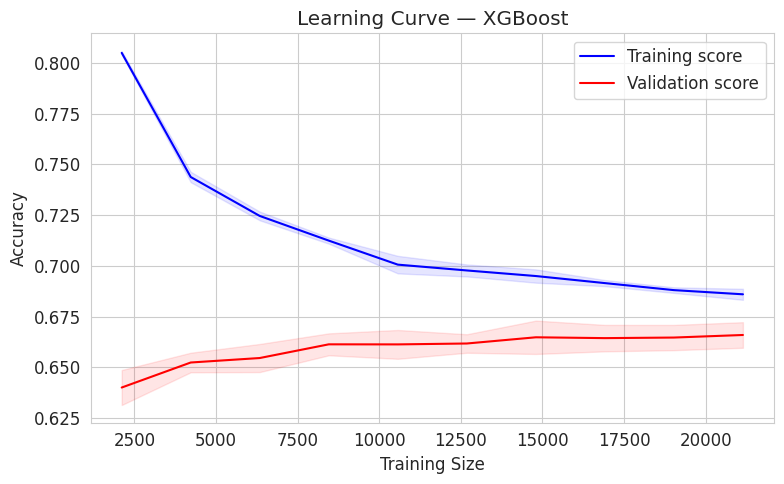

In [73]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, name, x, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model, x, y,
        cv=3,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    #Trains the model 10 times — starting with 10% of data, then 20%, 30%... up to 100%. At each size it uses 3-fold CV and records training and validation accuracy.

    train_mean = train_scores.mean(axis=1)
    #Averages the 3 CV scores at each training size into one number.(validation)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, label='Training score', color='blue')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    #The shaded area around each line shows the uncertainty/variance across the 3 folds.
    plt.plot(train_sizes, val_mean, label='Validation score', color='red')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')

    plt.title(f'Learning Curve — {name}')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'learning_curve_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# plot for each model
skip = ['SVC rbf']
#it's my worse model &will take forever to run so i skipped it
for name, (model, _) in models_proba.items():
    if name in skip:
        continue
    plot_learning_curve(model, name, x_train_clf, y_train_clf)

shap:

In [74]:
!pip install shap

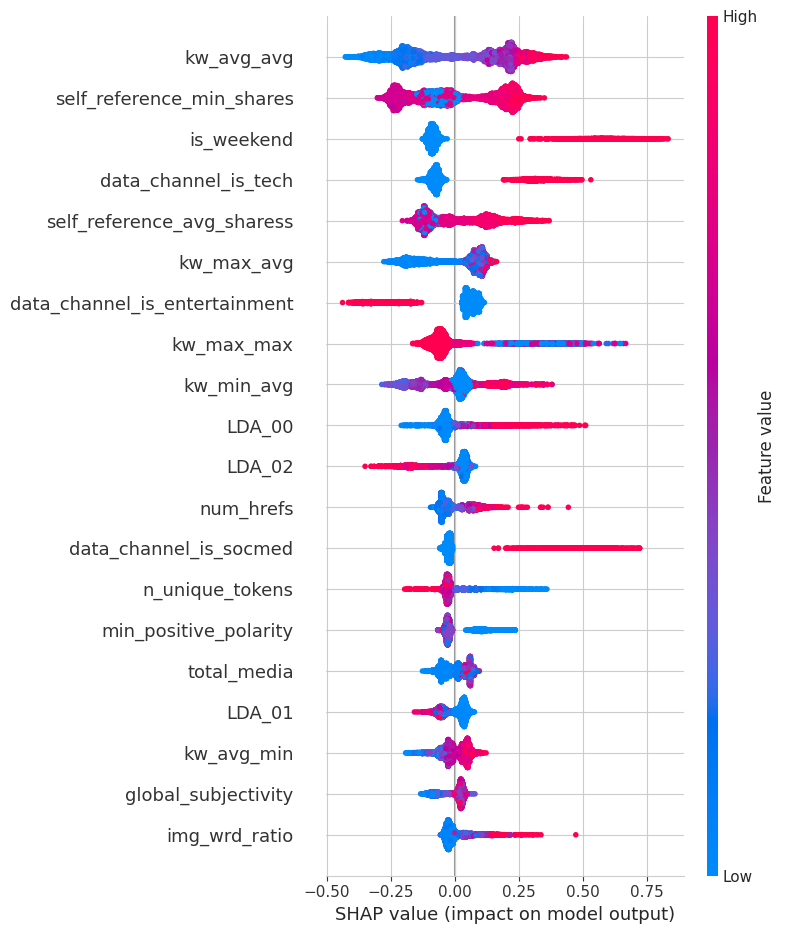

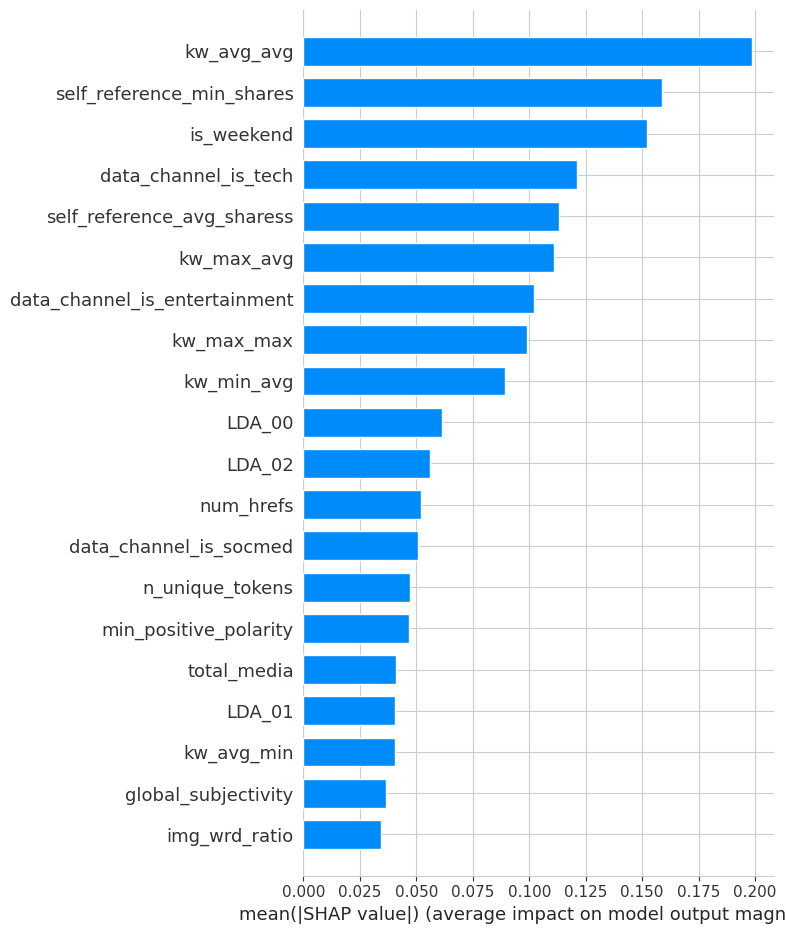

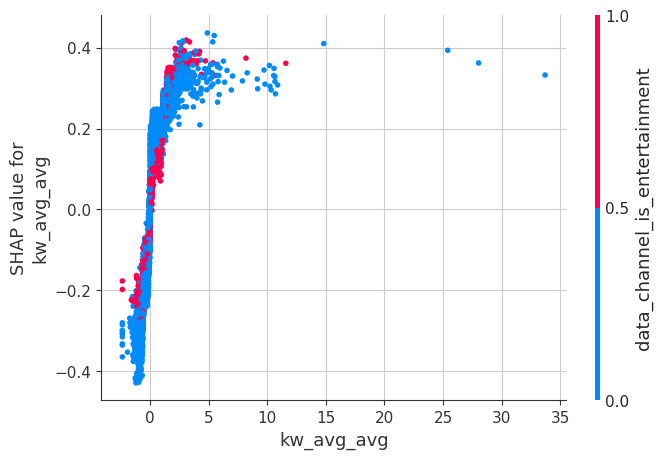

In [75]:
import shap

# used XGBoost as my best model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(x_test_clf)

# 1. Summary Plot
shap.summary_plot(shap_values, x_test_clf, feature_names=final_features)

# 2. Feature Importance Plot (bar)
shap.summary_plot(shap_values, x_test_clf, plot_type='bar', feature_names=final_features)

# 3. Dependence Plot (top feature)
top_feature = x_test_clf.columns[np.abs(shap_values).mean(axis=0).argmax()]
shap.dependence_plot(top_feature, shap_values, x_test_clf)

what happens when i train my model on less data ?:(robustness/stress testing)

training size10%: accuracy=0.6512
training size30%: accuracy=0.6659
training size50%: accuracy=0.6640
training size99%: accuracy=0.6660


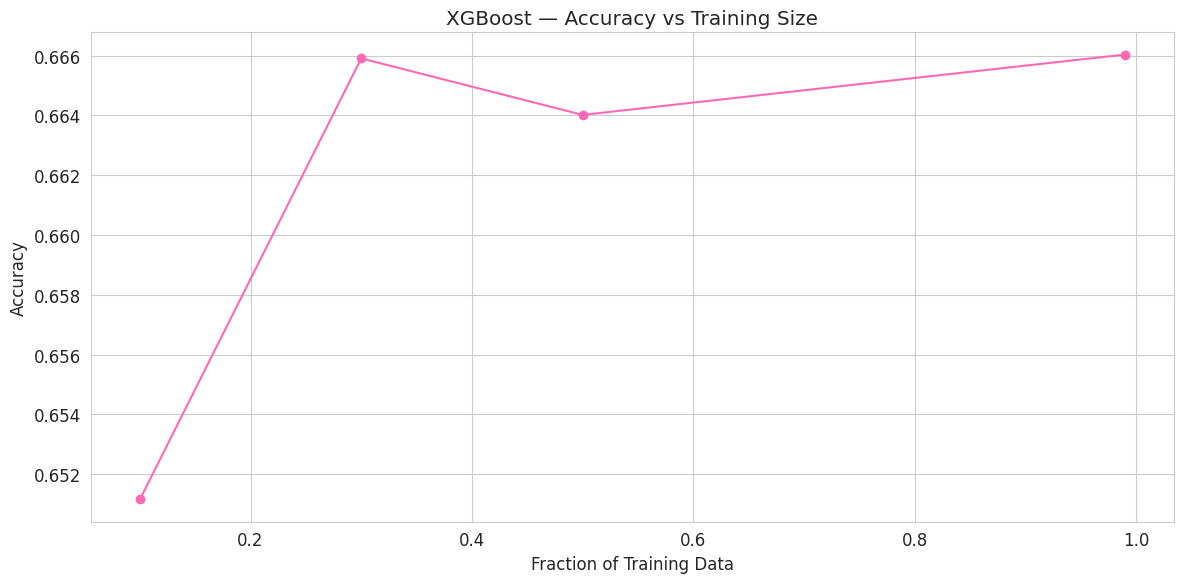

In [79]:
from sklearn.metrics import accuracy_score

fractions=[0.1,0.3,0.5,0.99]
#4 training sizes to test of training data .
results_robustness =[]

for frac in fractions :
    x_frac,_,y_frac,_ = train_test_split(
    x_train_clf,y_train_clf,
    train_size=frac,
    random_state=42
)
#randomly picking a fraction of my training(only train) data.

#testing on my "best model" ,xgboost:
    xgb_temp=XGBClassifier(n_estimator=100,max_depth=3,learning_rate=0.1,tree_method='hist',random_state=42,n_jobs=-1,eval_metric='logloss')
    xgb_temp.fit(x_frac,y_frac)
    acc=accuracy_score(y_test_clf,xgb_temp.predict(x_test_clf))
     #test it on the full test set every time,same test set, only training size changes,this makes the comparison fair.
    results_robustness.append({
    "fraction of training data":frac,
    "test accuracy":acc
    })
    print(f"training size{int(frac*100)}%: accuracy={acc:.4f}")

#plotting

# The current results_robustness list has keys 'fraction of training data' and 'test accuracy'
# The plotting section is trying to access 'fraction' and 'accuracy'
# I'll update the plotting code to match the keys in results_robustness.
fracs=[r['fraction of training data'] for r in results_robustness]
accs=[r['test accuracy'] for r in results_robustness]
#extracts the fractions and accuracies from the results list into two separate lists for plotting.
plt.plot(fracs,accs,marker='o',color='hotpink')
plt.title('XGBoost — Accuracy vs Training Size')
plt.xlabel('Fraction of Training Data')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig('robustness_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()